In [1]:
# dictionaries
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm, uniform, beta, norm, gamma
from scipy.optimize import brentq
from scipy.optimize import root
import pandas as pd
from scipy.special import logit
from matplotlib.lines import Line2D
from typing import Optional
from scipy.special import betaln, psi
from matplotlib.colors import to_rgba
from scipy.optimize import minimize_scalar, minimize
import seaborn as sns
from scipy import stats
from tqdm import tqdm
from decimal import Decimal, getcontext
import os
from matplotlib.ticker import ScalarFormatter, MaxNLocator
from scipy.stats import beta as sp_beta
from scipy.stats import beta as beta_dist 
from __future__ import annotations
from typing import Callable, Tuple
from scipy.stats import gamma as gamma_dist
from pathlib import Path
import math
from scipy.special import digamma
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import f_regression
from sklearn.metrics import r2_score
from scipy.stats import spearmanr
from scipy.stats import skew, kurtosis
import statsmodels.api as sm
import sys
from mpmath import mp, log, beta as mpbeta, nsum, quad, findroot, re, im
import itertools
from functools import partial
from concurrent.futures import ProcessPoolExecutor, as_completed
from math           import sqrt, log1p, erfc
from scipy.signal import savgol_filter
from collections import defaultdict
from scipy.integrate import trapezoid
from typing import Tuple, Dict, List

# Fig. 1: figure_max_variance_distributions

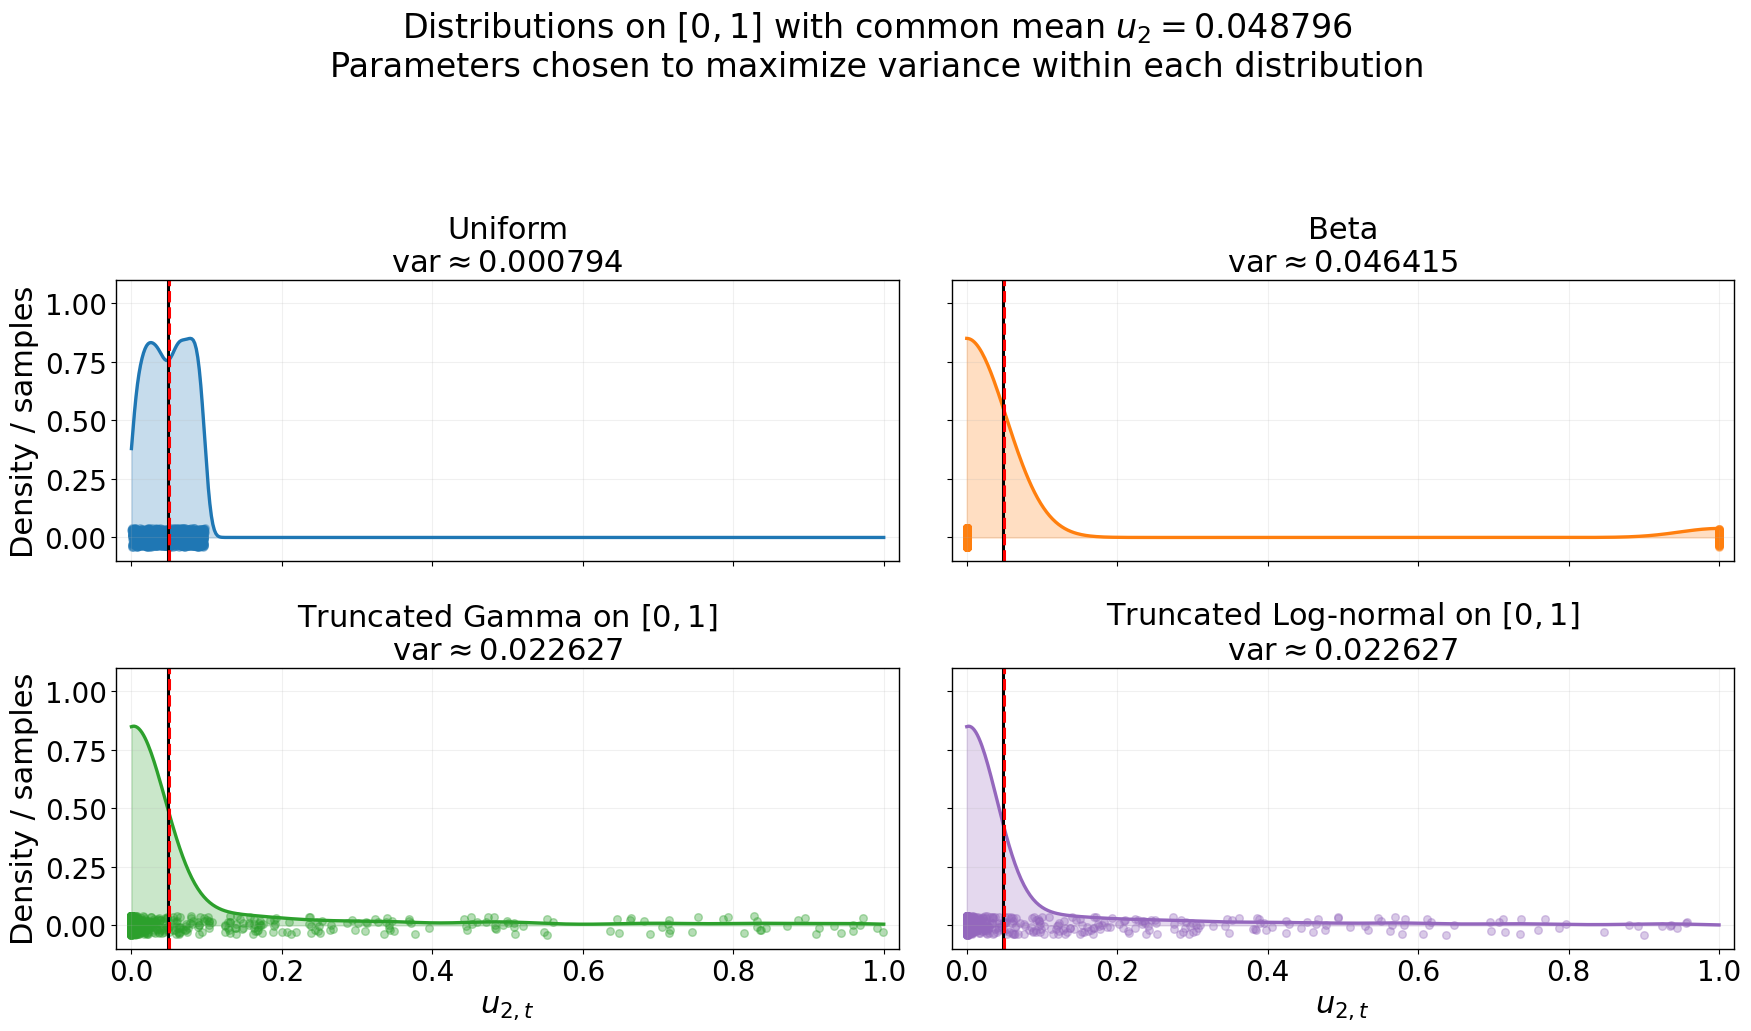

In [9]:

import numpy as np
import matplotlib.pyplot as plt
from scipy import special, optimize
from scipy.stats import gamma as gamma_dist, truncnorm
from scipy.special import log_ndtr

np.random.seed(12345)

# -------------------------------------------------------------------
# Targets
# -------------------------------------------------------------------
u1 = 0.05
u2 = 0.048796   # common mean for ALL panels

plt.rcParams.update({
    "font.size": 22,
    "axes.titlesize": 22,
    "axes.labelsize": 22,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
})

# -------------------------------------------------------------------
# Simple 1D Gaussian KDE
# -------------------------------------------------------------------
def kde_from_samples(samples, xs):
    samples = np.asarray(samples)
    xs = np.asarray(xs)
    n = len(samples)
    if n < 2:
        return np.zeros_like(xs)
    s = np.std(samples, ddof=1) or 1e-6
    h = max(1.06 * s * n ** (-1.0 / 5.0), 1e-3)
    diff = (xs[:, None] - samples[None, :]) / h
    return np.exp(-0.5 * diff**2).sum(axis=1) / (n * h * np.sqrt(2*np.pi))

# ==========================================================
# Distributions with largest feasible variance (within family)
# ==========================================================

# 1) Uniform on [0,1] with mean u2
a_uni, b_uni = 0.0, 2.0 * u2
var_uni = (b_uni - a_uni) ** 2 / 12.0

# 2) Beta on [0,1], high-variance regime with fixed mean
c_beta = 1e-6
alpha, beta = c_beta * u2, c_beta * (1 - u2)
var_beta = alpha * beta / (((alpha + beta) ** 2) * (alpha + beta + 1))

# 3) Truncated Gamma on [0,1], mean fixed to u2
def trunc_gamma_moments(k, theta):
    x = 1.0 / theta
    F = special.gammainc(k, x)
    m1 = theta * special.gamma(k+1) * special.gammainc(k+1, x) / special.gamma(k) / F
    m2 = theta**2 * special.gamma(k+2) * special.gammainc(k+2, x) / special.gamma(k) / F
    return m1, m2 - m1**2

def gamma_theta_for_mean(k):
    f = lambda th: trunc_gamma_moments(k, th)[0] - u2
    return optimize.brentq(f, 1e-12, 1e12)

k_star = u2 / (1 - u2)
k_gamma = k_star + 1e-6
theta_gamma = gamma_theta_for_mean(k_gamma)
_, var_gamma = trunc_gamma_moments(k_gamma, theta_gamma)

def sample_truncated_gamma(n):
    dist = gamma_dist(a=k_gamma, scale=theta_gamma)
    Fu = dist.cdf(1.0)
    return dist.ppf(np.random.rand(n) * Fu)

# 4) Truncated Log-normal on [0,1], mean fixed to u2
def trunc_logn_moments(m, s):
    logF = log_ndtr(-m / s)
    m1 = np.exp((m + 0.5*s*s) + log_ndtr(-(m + s*s)/s) - logF)
    m2 = np.exp((2*m + 2*s*s) + log_ndtr(-(m + 2*s*s)/s) - logF)
    return m1, m2 - m1**2

def logn_m_for_mean(s):
    g = lambda m: trunc_logn_moments(m, s)[0] - u2
    return optimize.brentq(g, -5000.0, 1e6)

s_logn = 800.0
m_logn = logn_m_for_mean(s_logn)
_, var_logn = trunc_logn_moments(m_logn, s_logn)

def sample_truncated_lognormal(n):
    b = (0.0 - m_logn) / s_logn
    Y = truncnorm.rvs(-np.inf, b, loc=m_logn, scale=s_logn, size=n)
    return np.exp(Y)

# ==========================================================
# Plot
# ==========================================================
N = 1200
xs = np.linspace(0, 1, 500)

fig, axes = plt.subplots(2, 2, figsize=(18, 11), sharex=True, sharey=True)
axes = axes.ravel()
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#9467bd"]

def panel(ax, samples, color, title):
    ys = kde_from_samples(samples, xs)
    ys = ys / (ys.max() if ys.max() > 0 else 1.0)
    jitter = (np.random.rand(len(samples)) - 0.5) * 0.08
    ax.scatter(samples, jitter, s=30, alpha=0.35, color=color)
    ax.fill_between(xs, 0, 0.85*ys, color=color, alpha=0.25)
    ax.plot(xs, 0.85*ys, color=color, linewidth=2.4)
    ax.axvline(u2, color="black", linewidth=2.2)
    ax.axvline(u1, color="red", linestyle="--", linewidth=2.2)
    ax.set_title(title)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.10, 1.10)
    ax.grid(alpha=0.18)

panel(axes[0],
      np.random.uniform(a_uni, b_uni, N),
      colors[0],
      rf"Uniform"+"\n"+rf"$\mathrm{{var}}\approx {var_uni:.6f}$")

panel(axes[1],
      np.random.beta(alpha, beta, N),
      colors[1],
      rf"Beta"+"\n"+rf"$\mathrm{{var}}\approx {var_beta:.6f}$")

panel(axes[2],
      sample_truncated_gamma(N),
      colors[2],
      rf"Truncated Gamma on $[0,1]$"+"\n"+rf"$\mathrm{{var}}\approx {var_gamma:.6f}$")

panel(axes[3],
      sample_truncated_lognormal(N),
      colors[3],
      rf"Truncated Log-normal on $[0,1]$"+"\n"+rf"$\mathrm{{var}}\approx {var_logn:.6f}$")

for ax in axes[2:]:
    ax.set_xlabel(r"$u_{2,t}$")
for ax in (axes[0], axes[2]):
    ax.set_ylabel("Density / samples")

fig.suptitle(
    rf"Distributions on $[0,1]$ with common mean $u_2 = {u2:.6f}$"
    "\nParameters chosen to maximize variance within each distribution",
    fontsize=24
)

plt.tight_layout(rect=[0, 0.03, 1, 0.92])
plt.show()


# Haploid Population


End‑to‑end **deterministic pipeline** for the haploid two‑locus mutation‑rate modifier model.
How the pipeline works:
1. **Feasibility grid**   Builds a Cartesian product of means (0, MEAN_MAX] and variances (0, VAR_MAX] and keeps only those that yield positive Beta(α, β)
   parameters.
2. **Bifurcation search**   Choose the two feasible Beta rows whose means are closest *below* and *above* a threshold `THRESH_MEAN`.  Simulate invasion for both distributions across a resident‑rate interval `[U1_MIN, U1_MAX]`. Find the *first* sign‑change of `ΔM2 = M2_high − M2_low` and refine it with a bisection to get `u1_star`.
3. **Full sweep**   Run all feasible (μ, σ²) pairs at that `u1_star` and record the final M₁/M₂ frequencies.
4. **Plot**   Scatter of mean vs variance coloured by fixation outcome.


In [4]:
# ---------------------------------------------------------------------------
#  constants – tweak here only
# ---------------------------------------------------------------------------
UPPER: float = 1.0         # scaling factor(domain 0..UPPER)
LOWER: float = 0.0           # lower bound (kept for explicitness)

# Grid resolution & bounds for the feasibility scan
MEAN_MAX: float = 0.07      # search μ   ∈ (0, MEAN_MAX]
VAR_MAX: float = 0.1    # search σ² ∈ (0, VAR_MAX]
N_MEAN: int = 500
N_VAR: int  =  500

# Simulation parameters
GENS: int = 5_000            # generations per invasion trial
SEL_S: float = 0.2           # viability selection (A:1, a:1−s)
RECOMB_R: float = 0.0       # recombination between loci

# Seeds for reproducibility (set to None for full randomness)
SEED_GLOBAL: int | None = 42
np.random.seed(SEED_GLOBAL)

# Bifurcation search settings
THRESH_MEAN: float = 0.04     # sharply splits "low" vs. "high" mean classes
U1_MIN: float = 1e-7      # explore low resident mutation rates
U1_MAX: float = 0.06          # upper limit; most bifurcations will occur below this
BIFUR_STEPS: int = 3_000     # coarse resolution before bisection refinement
BISECTION_ITERS: int = 25    # extra bits of precision after sign‑flip detected

# File locations
CSV_FEAS: str = "Simulations/s1_beta_feasibility_grid.csv"
CSV_SWEEP: str = "Simulations/s2_beta_simulation_results.csv"


In [3]:

# ---------------------------------------------------------------------------
# Helper: Beta (α,β) from required mean & variance
# ---------------------------------------------------------------------------
def beta_from_moments(mu: np.ndarray,
                      var: np.ndarray,
                      UPPER: float = 1.0
                      ) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return α, β and a feasibility mask for target mean/variance on [0, UPPER]."""
    mu_hat  = mu / UPPER
    var_hat = var / UPPER**2

    # Feasible if 0 < mu < 1 and 0 < var < m(1-m)
    denom     = mu_hat * (1 - mu_hat) - var_hat
    feasible  = (mu_hat > 0) & (mu_hat < 1) & (var_hat > 0) & (denom > 0)

    # Avoid division by zero with where()
    common    = np.where(feasible,
                         mu_hat * (1 - mu_hat) / var_hat - 1,
                         np.nan)

    alpha     = mu_hat  * common
    beta      = (1 - mu_hat) * common
    return alpha, beta, feasible

# ---------------------------------------------------------------------------
# Sampler factory for u₂,t values
# ---------------------------------------------------------------------------
def make_beta_sampler(alpha: float,
                      beta_val: float,
                      *,
                      upper: float = UPPER,
                      rng: np.random.Generator | None = None
                      ) -> Callable[[int], np.ndarray]:
    """
    Return a closure draw_u2(n) that produces n draws from Beta(α,β),
    scaled to [0, upper].
    """
    _rng = rng if rng is not None else np.random.default_rng()
    def _draw(n: int) -> np.ndarray:
        return beta_dist.rvs(alpha, beta_val, size=n, random_state=_rng) * upper
    return _draw

# ---------------------------------------------------------------------------
# Two‑locus haploid recursion
# ---------------------------------------------------------------------------
def simulate_haploid_invasion(
    u1: float,
    draw_u2: Callable[[int], np.ndarray],
    *,
    generations: int = GENS,
    s: float = SEL_S,
    R: float = RECOMB_R,
) -> Tuple[float, float]:
    """Return final (M1, M2) frequencies after *generations* iterations."""
    assert 0 <= u1 <= 1, "u1 must lie in [0,1]"
    assert 0 <= R <= 0.5, "R should be a recombination fraction in [0,0.5]"

    eps = 1e-3
    x1, x2, x3, x4 = 0.75 - eps, 0.25 - eps, eps, eps

    u2_series = draw_u2(generations)
    W_A, W_a = 1.0, 1.0 - s

    for t in range(generations):
        u2 = u2_series[t]
        if not (0 <= u2 <= 1):
            raise ValueError(f"u2[{t}]={u2} outside [0,1]")

        # 1. Viability selection
        W_bar = (x1 + x3) * W_A + (x2 + x4) * W_a
        x1, x2, x3, x4 = (
            x1 * W_A / W_bar,
            x2 * W_a / W_bar,
            x3 * W_A / W_bar,
            x4 * W_a / W_bar,
        )

        # 2. Recombination
        if R > 0:
            D = x1 * x4 - x2 * x3
            x1 -= R * D
            x2 += R * D
            x3 += R * D
            x4 -= R * D

        # 3. Forward mutation A → a
        x1_new = x1 * (1 - u1)
        x2_new = x2 + x1 * u1
        x3_new = x3 * (1 - u2)
        x4_new = x4 + x3 * u2

        # 4. Renormalise
        total = x1_new + x2_new + x3_new + x4_new
        x1, x2, x3, x4 = (
            x1_new / total,
            x2_new / total,
            x3_new / total,
            x4_new / total,
        )

    return x1 + x2, x3 + x4


In [76]:

# ---------------------------------------------------------------------------
# Build / load the feasibility grid
# ---------------------------------------------------------------------------
def build_beta_feasibility_grid() -> pd.DataFrame:
    """Generate a grid of (mean, var) pairs that admit a Beta(α,β) and save to CSV."""
    mean_grid = np.linspace(1e-10, UPPER, N_MEAN, dtype=np.float64)
    var_grid  = np.linspace(1e-10, VAR_MAX, N_VAR, dtype=np.float64)
    M, V = np.meshgrid(mean_grid, var_grid, indexing="ij")

    α, β, feas = beta_from_moments(M, V)

    df = pd.DataFrame({
        "mean":       M[feas].ravel(),
        "var":        V[feas].ravel(),
        "beta_alpha": α[feas].ravel(),
        "beta_beta":  β[feas].ravel(),
    })

    # Optional: drop the always‑True column unless you plan to append infeasible rows later
    df["beta_feasible"] = True

    Path(CSV_FEAS).parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(CSV_FEAS, index=False, float_format="%.10g")
    print(f"✓ Feasibility grid saved to {CSV_FEAS}  ({len(df):,} points)")
    return df


In [77]:
# ---------------------------------------------------------------------------
# Bifurcation finder
# ---------------------------------------------------------------------------
# ------------------------------------------------------------------
# 1. Bracket the threshold on the grid
# ------------------------------------------------------------------
def pick_bracketing_means(df: pd.DataFrame, threshold: float) -> Tuple[float, float]:
    """Return (μ_low, μ_high) such that μ_low < threshold < μ_high."""
    mask_low  = df["mean"] < threshold
    mask_high = df["mean"] > threshold
    if not mask_low.any() or not mask_high.any():
        print("Available mean values (min → max):", df["mean"].min(), "→", df["mean"].max())
        print("Unique means near threshold:", df["mean"].loc[(df["mean"] > 0.015) & (df["mean"] < 0.025)].unique())

        raise ValueError("Threshold outside the available grid range.")

    mu_low  = df.loc[mask_low , "mean"].max()
    mu_high = df.loc[mask_high, "mean"].min()

    # If threshold hits a grid point, nudge to the immediate neighbours
    if np.isclose(mu_low, mu_high):
        candidates = np.sort(df["mean"].unique())
        idx = np.where(np.isclose(candidates, mu_low))[0][0]
        mu_low  = candidates[max(idx - 1, 0)]
        mu_high = candidates[min(idx + 1, len(candidates) - 1)]
    return mu_low, mu_high

# ------------------------------------------------------------------
# 2. Build a sampler from a dataframe row
# ------------------------------------------------------------------
def sampler_from_row(row: pd.Series) -> Callable[[int], np.ndarray]:
    return make_beta_sampler(
        float(row["beta_alpha"]),
        float(row["beta_beta"]),
        upper=UPPER
    )

# ------------------------------------------------------------------
# 3. Core bifurcation finder
# ------------------------------------------------------------------
def find_bifurcation_u1(low_sampler: Callable[[int], np.ndarray],
                        high_sampler: Callable[[int], np.ndarray],
                        *,
                        bifur_steps: int = BIFUR_STEPS,
                        bisect_iters: int = BISECTION_ITERS) -> float:
    """Return the smallest u1 where  M2_high − M2_low  changes sign (−→+)."""

    # helper closed over the two samplers
    def diff_at(u1: float) -> float:
        _, m2_low  = simulate_haploid_invasion(u1, low_sampler)
        _, m2_high = simulate_haploid_invasion(u1, high_sampler)
        return m2_high - m2_low

    # 3a. coarse scan
    u1_vals = np.linspace(U1_MIN, U1_MAX, bifur_steps)
    diff = np.array([diff_at(u1) for u1 in tqdm(u1_vals, desc="Scanning u1")])

    # handle exact zeros so they don't mask a flip
    sign = np.sign(diff)
    zeros = np.where(sign == 0)[0]
    for z in zeros:
        sign[z] = sign[z-1] if z > 0 else 1

    flips = np.where(np.diff(sign) != 0)[0]
    if flips.size == 0:
        return U1_MAX

    i      = flips[0]
    a, b   = u1_vals[i], u1_vals[i + 1]
    f_a    = diff[i]

    # 3b. bisection refinement
    for _ in range(bisect_iters):
        mid  = 0.5 * (a + b)
        f_mid = diff_at(mid)
        if f_mid * f_a > 0:   # same sign → root in (mid, b]
            a, f_a = mid, f_mid
        else:                 # root in [a, mid]
            b = mid
    return 0.5 * (a + b)

# ------------------------------------------------------------------
# 4. Top‑level convenience wrapper
# ------------------------------------------------------------------
def critical_u1_threshold(threshold: float,
                          df: pd.DataFrame,
                          *,
                          bifur_steps: int = BIFUR_STEPS,
                          bisect_iters: int = BISECTION_ITERS) -> float:
    """
    Compute the critical u1 where invasion outcome flips
    when comparing two µ₂ means bracketing *threshold*.
    """
    mu_low,  mu_high  = pick_bracketing_means(df, threshold)
    row_low  = df.loc[np.isclose(df["mean"], mu_low)].iloc[0]
    row_high = df.loc[np.isclose(df["mean"], mu_high)].iloc[0]

    low_sampler  = sampler_from_row(row_low)
    high_sampler = sampler_from_row(row_high)

    return find_bifurcation_u1(low_sampler, high_sampler,
                               bifur_steps=bifur_steps,
                               bisect_iters=bisect_iters)



### Beta Distribution

✓ Feasibility grid saved to Simulations/s1_beta_feasibility_grid.csv  (222,562 points)


Scanning u1: 100%|██████████| 3000/3000 [00:20<00:00, 143.20it/s]



Located bifurcation resident rate  u1* ≈ 0.048796284095



Simulating full grid: 100%|██████████| 222562/222562 [14:16<00:00, 259.89it/s]


✓ Sweep results saved to Simulations/s2_beta_simulation_results.csv  (222,562 runs)


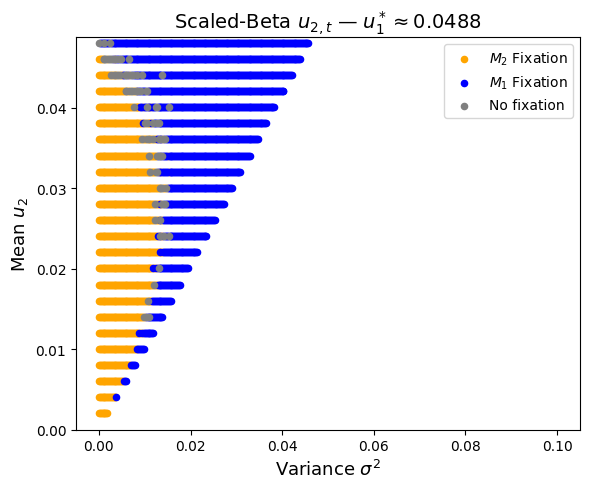

In [78]:
def main() -> None:
    # -------------------------------------------------------------
    # 1. Load/build feasibility grid
    # -------------------------------------------------------------
    grid_path = Path(CSV_FEAS)
    if grid_path.is_file():
        grid = pd.read_csv(grid_path)
        print(f"✓ Loaded feasibility grid ({len(grid):,} points)")
    else:
        grid = build_beta_feasibility_grid()

    # -------------------------------------------------------------
    # 2. Locate critical resident mutation rate u1*
    # -------------------------------------------------------------
    u1_star = critical_u1_threshold(THRESH_MEAN, grid)
    print(f"\nLocated bifurcation resident rate  u1* ≈ {u1_star:.12f}\n")
     
    # -------------------------------------------------------------
    # 3. Sweep every feasible (mean, var) point at that u1*
    # -------------------------------------------------------------
    results = []
    for row in tqdm(grid.itertuples(index=False),
                    total=len(grid),
                    desc="Simulating full grid"):
        draw_u2 = make_beta_sampler(row.beta_alpha,
                                    row.beta_beta,
                                    upper=UPPER)
        m1, m2 = simulate_haploid_invasion(u1_star, draw_u2)
        results.append((row.mean, row.var, m1, m2))

    sweep_df = pd.DataFrame(results,
                            columns=["mean", "var", "M1_final", "M2_final"])
    Path(CSV_SWEEP).parent.mkdir(parents=True, exist_ok=True)
    sweep_df.to_csv(CSV_SWEEP, index=False)
    print(f"✓ Sweep results saved to {CSV_SWEEP}  ({len(sweep_df):,} runs)")

    # -------------------------------------------------------------
    # 4. Plot outcome
    # -------------------------------------------------------------
    plt.figure(figsize=(6, 5))
    m2_dom = sweep_df["M2_final"] > 0.99
    m1_dom = sweep_df["M1_final"] > 0.99

    plt.scatter(sweep_df.loc[m2_dom, "var"],
                sweep_df.loc[m2_dom, "mean"],
                s=20, color="orange", label="$M_2$ Fixation")
    plt.scatter(sweep_df.loc[m1_dom, "var"],
                sweep_df.loc[m1_dom, "mean"],
                s=20, color="blue",  label="$M_1$ Fixation")
    plt.scatter(sweep_df.loc[~(m1_dom | m2_dom), "var"],
                sweep_df.loc[~(m1_dom | m2_dom), "mean"],
                s=20, color="gray",  label="No fixation")

    plt.xlabel(r"Variance $\sigma^2$", fontsize=13)
    plt.ylabel(r"Mean $u_2$", fontsize=13)
    plt.ylim(0, u1_star)
    plt.title(fr"Scaled‑Beta $u_{{2,t}}$ — $u_1^* \approx {u1_star:.4f}$",
              fontsize=14)
    plt.legend()
    plt.tight_layout()

    # Path(FIG_FILE).parent.mkdir(parents=True, exist_ok=True)
    # plt.savefig(FIG_FILE, dpi=300)
    # print(f"✓ Figure saved to {FIG_FILE}\n")
    plt.show()
    plt.close()


if __name__ == "__main__":
    main()

### Recombination on Beta

Simulating grid for R=0.5: 100%|██████████| 222562/222562 [14:15<00:00, 260.15it/s]


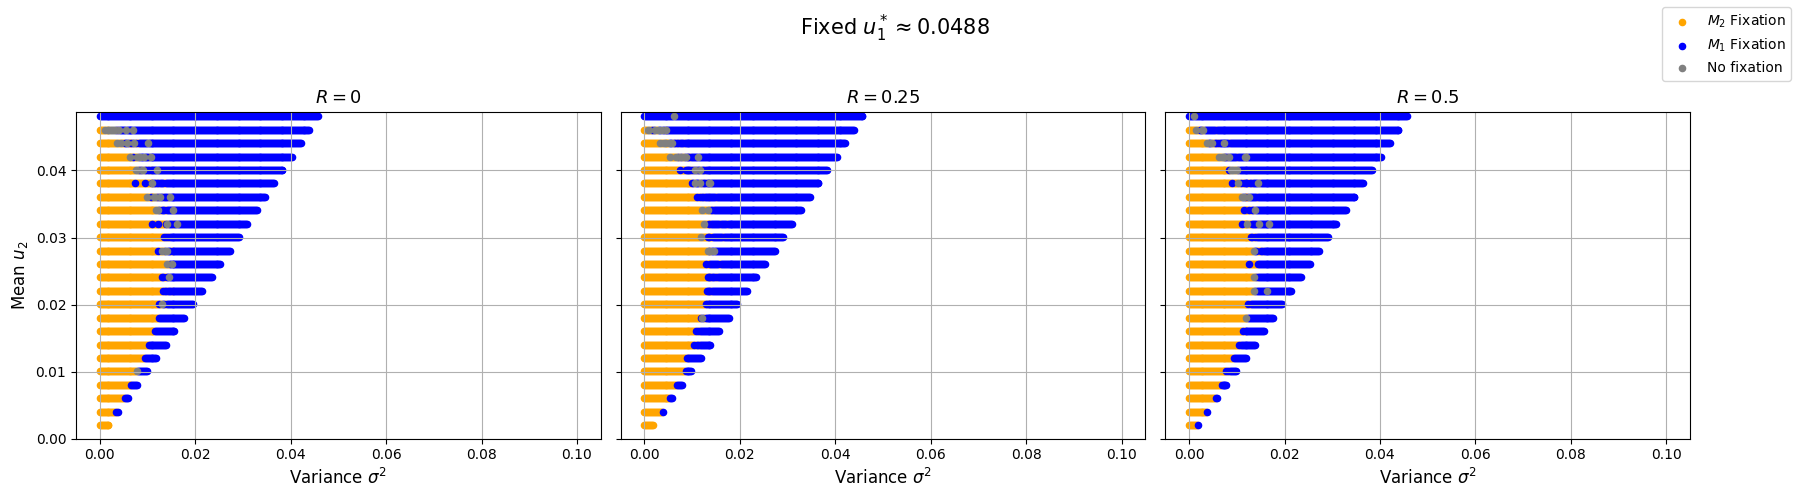

In [6]:
# Configurable constants
GENS: int = 15_000  
R_VALUES = [0, 0.25, 0.5]
FIXED_U1 = 0.048796284095  # Use this same u1 for all R values

def run_simulation_for_R(R_val):
    global R
    R = R_val  # Set global or module-level R

    # 1. Load or build feasibility grid
    grid_path = Path(CSV_FEAS)
    if grid_path.is_file():
        grid = pd.read_csv(grid_path)
    else:
        grid = build_beta_feasibility_grid()

    # 2. Sweep grid at fixed u1*
    results = []
    for row in tqdm(grid.itertuples(index=False),
                    total=len(grid),
                    desc=f"Simulating grid for R={R_val}"):
        draw_u2 = make_beta_sampler(row.beta_alpha,
                                    row.beta_beta,
                                    upper=UPPER)
        m1, m2 = simulate_haploid_invasion(FIXED_U1, draw_u2)
        results.append((row.mean, row.var, m1, m2))

    sweep_df = pd.DataFrame(results,
                            columns=["mean", "var", "M1_final", "M2_final"])
    return sweep_df

def main():
    fig, axes = plt.subplots(1, len(R_VALUES), figsize=(6 * len(R_VALUES), 5), sharey=True)

    if len(R_VALUES) == 1:
        axes = [axes]

    for ax, R_val in zip(axes, R_VALUES):
        sweep_df = run_simulation_for_R(R_val)

        m2_dom = sweep_df["M2_final"] > 0.9
        m1_dom = sweep_df["M1_final"] > 0.9

        ax.scatter(sweep_df.loc[m2_dom, "var"],
                   sweep_df.loc[m2_dom, "mean"],
                   s=20, color="orange", label="$M_2$ Fixation")
        ax.scatter(sweep_df.loc[m1_dom, "var"],
                   sweep_df.loc[m1_dom, "mean"],
                   s=20, color="blue", label="$M_1$ Fixation")
        ax.scatter(sweep_df.loc[~(m1_dom | m2_dom), "var"],
                   sweep_df.loc[~(m1_dom | m2_dom), "mean"],
                   s=20, color="gray", label="No fixation")

        ax.set_title(fr"$R = {R_val}$", fontsize=13)
        ax.set_xlabel(r"Variance $\sigma^2$", fontsize=12)
        ax.set_ylim(0, FIXED_U1)
        ax.grid(True)

    axes[0].set_ylabel(r"Mean $u_2$", fontsize=12)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.suptitle(fr"Fixed $u_1^* \approx {FIXED_U1:.4f}$", fontsize=15)
    fig.legend(handles, labels, loc='upper right')
    plt.tight_layout(rect=[0, 0, 0.95, 0.95])
    plt.show()

if __name__ == "__main__":
    main()


### Uniform Distribution

Mean loop: 100%|██████████| 200/200 [02:18<00:00,  1.45it/s]

✓ 39,797 feasible (μ,σ²) points written → Simulations/s3_uniform_simulation_results.csv


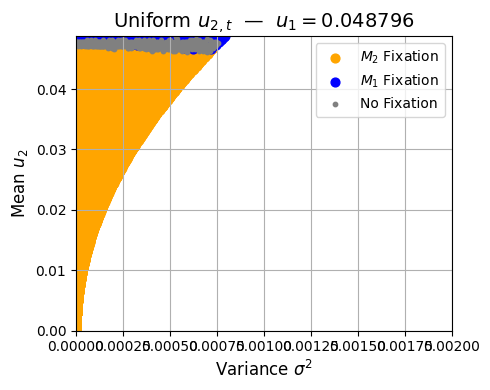

In [80]:

U_LOWER, U_UPPER = 0.0, 1.0
N_MEANS = 200   # number of mean points (you can adjust for finer grid)
N_VARS  = 200    # number of variances per mean (finer near boundary)
OUTFILE   = Path("Simulations/s3_uniform_simulation_results.csv")
SEED      = 0
CHOSEN_U1 = 0.048796284095  # resident mutation rate u1*

def main():
    if SEED is not None:
        np.random.seed(SEED)
        rng = np.random.default_rng(SEED)
    else:
        rng = np.random.default_rng()

    # --- 1. Loop over mean first
    mean_vals = np.linspace(1e-10, CHOSEN_U1, N_MEANS)

    results = []
    for mean in tqdm(mean_vals, desc="Mean loop"):
        k_max = min(mean, U_UPPER - mean)
        if k_max <= 0:
            continue
        var_max = (k_max**2) / 3
        var_vals = np.linspace(1e-10, var_max, N_VARS)
        for var in var_vals:
            k = math.sqrt(3 * var)
            a, b = mean - k, mean + k
            if a < U_LOWER or b > U_UPPER or a >= b:
                continue
            draw_u2 = lambda n, a=a, b=b, _rng=rng: _rng.uniform(a, b, size=n)
            m1, m2 = simulate_haploid_invasion(CHOSEN_U1, draw_u2)
            results.append((mean, var, m1, m2))

    df = pd.DataFrame(results, columns=["mean", "var", "M1_final", "M2_final"])
    OUTFILE.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(OUTFILE, index=False)
    print(f"✓ {len(df):,} feasible (μ,σ²) points written → {OUTFILE}")

    # --- 2. Plot
    plt.figure(figsize=(5, 4))
    m2_dom = df["M2_final"] > 0.90
    m1_dom = df["M1_final"] > 0.90
    plt.scatter(df.loc[m2_dom, "var"], df.loc[m2_dom, "mean"],
                color="orange", s=40, label="$M_2$ Fixation")
    plt.scatter(df.loc[m1_dom, "var"], df.loc[m1_dom, "mean"],
                color="blue",   s=40, label="$M_1$ Fixation")
    plt.scatter(df.loc[~(m1_dom | m2_dom), "var"],
                df.loc[~(m1_dom | m2_dom), "mean"],
                color="gray",   s=10, label="No Fixation")

    plt.xlabel(r"Variance $\sigma^2$", fontsize=12)
    plt.ylabel(r"Mean $u_2$", fontsize=12)
    plt.title(rf"Uniform $u_{{2,t}}$  —  $u_1 = {CHOSEN_U1:.5g}$", fontsize=14)
    plt.grid(True)
    plt.ylim(0, CHOSEN_U1)
    plt.xlim(0, 0.002)
    plt.legend()
    plt.tight_layout()
    plt.show()
    plt.close()

if __name__ == "__main__":
    main()

### Log-Normal Distribution

In [81]:
# ---------------------------------------------------------------------------
# Parameters
# ---------------------------------------------------------------------------
LOWER, UPPER = 0.0, 1.0                    # domain of u₂,t
GENERATIONS  = 5_000
SEED         = 0
np.random.seed(SEED)

CHOSEN_U1 = 0.048796284095                 # resident mutation rate
OUT_FEAS  = Path("Simulations/s4_lognorm_feasible_grid.csv")
OUT_SWEEP = Path("Simulations/s5_lognorm_simulation_results.csv")

os.makedirs("Simulations", exist_ok=True)

# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------
def lognorm_mu_sigma(mean: float, var: float) -> Tuple[float, float] | None:
    """Return (mu, sigma) parameters of a log‑normal with given mean & variance."""
    if mean <= 0 or var <= 0:
        return None
    sigma2 = math.log1p(var / mean**2)
    return math.log(mean) - 0.5 * sigma2, math.sqrt(sigma2)

def make_lognorm_sampler(mu: float, sigma: float,
                         *,
                         upper: float = UPPER,
                         rng: np.random.Generator | None = None):
    """Return draw_u2(n) that samples *truncated* log‑normal on [LOWER, upper]."""
    _rng = rng if rng is not None else np.random.default_rng()
    def _draw(n: int) -> np.ndarray:
        x = _rng.lognormal(mean=mu, sigma=sigma, size=n)
        # hard clip; probability above upper is ≤ 1e‑6, but this guarantees bound
        return np.clip(x, LOWER, upper)
    return _draw

# ---------------------------------------------------------------------------
# Feasible (μ, σ²) grid
# ---------------------------------------------------------------------------
mean_vals = np.linspace(1e-10, CHOSEN_U1, 500)
var_vals  = np.linspace(1e-10, 0.005, 500)

rows = []
for mean in mean_vals:
    for var in var_vals:
        params = lognorm_mu_sigma(mean, var)
        if params is None:
            continue
        mu, sigma = params
        cdf_upper = lognorm.cdf(UPPER, s=sigma, scale=math.exp(mu))
        if cdf_upper >= 0.9999999:            # ≥ 99.999 % mass below UPPER
            rows.append((mean, var, mu, sigma))

viable_df = pd.DataFrame(rows, columns=["mean", "var", "mu", "sigma"])
OUT_FEAS.parent.mkdir(parents=True, exist_ok=True)
viable_df.to_csv(OUT_FEAS, index=False)

# ---------------------------------------------------------------------------
# Simulation sweep
# ---------------------------------------------------------------------------
results = []
rng = np.random.default_rng(SEED)            # reuse same RNG for speed
for r in tqdm(viable_df.itertuples(index=False),
              total=len(viable_df),
              desc="Simulations"):
    sampler = make_lognorm_sampler(r.mu, r.sigma, rng=rng)
    m1, m2  = simulate_haploid_invasion(CHOSEN_U1, sampler)
    results.append((r.mean, r.var, m1, m2))

final_df = pd.DataFrame(results,
                        columns=["mean", "var", "M1_final", "M2_final"])
OUT_SWEEP.parent.mkdir(parents=True, exist_ok=True)
final_df.to_csv(OUT_SWEEP, index=False)

Simulations: 100%|██████████| 25899/25899 [01:33<00:00, 278.01it/s]


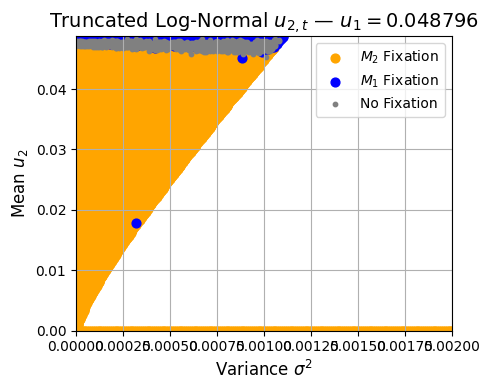

In [82]:
# ---------------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------------
plt.figure(figsize=(5, 4))
m2_dom = final_df["M2_final"] > 0.90
m1_dom = final_df["M1_final"] > 0.90

plt.scatter(final_df.loc[m2_dom, "var"], final_df.loc[m2_dom, "mean"],
            color="orange", s=40, label="$M_2$ Fixation")
plt.scatter(final_df.loc[m1_dom, "var"], final_df.loc[m1_dom, "mean"],
            color="blue",   s=40, label="$M_1$ Fixation")
plt.scatter(final_df.loc[~(m1_dom | m2_dom), "var"],
            final_df.loc[~(m1_dom | m2_dom), "mean"],
            color="gray",   s=10, label="No Fixation")

plt.xlabel(r"Variance $\sigma^2$", fontsize=12)
plt.ylabel(r"Mean $u_2$", fontsize=12)
plt.title(rf"Truncated Log‑Normal $u_{{2,t}}$ — $u_1 = {CHOSEN_U1:.5g}$",
          fontsize=14)
plt.grid(True)
plt.ylim(0, CHOSEN_U1) 
plt.xlim(0, 0.002)                  # show full mean range
plt.legend()
plt.tight_layout()
plt.show()
plt.close()

### Truncated Gamma

Simulations: 100%|██████████| 9559/9559 [00:52<00:00, 182.25it/s]


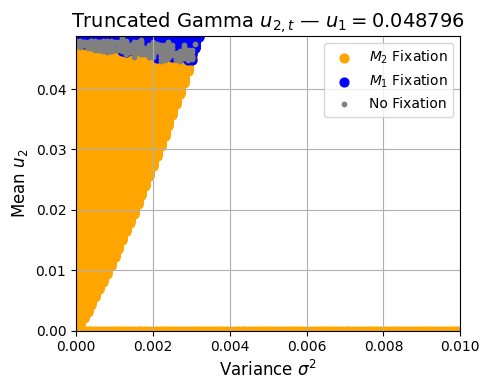

In [ ]:
# ---------------------------------------------------------------------------
# Parameters
# ---------------------------------------------------------------------------
LOWER, UPPER = 0.0, 1.0                  # domain of u₂,t
GENERATIONS  = 5_000
SEED         = 0
np.random.seed(SEED)

CHOSEN_U1 = 0.048796284095                # resident mutation rate
OUT_FEAS  = Path("Simulations/s6_gamma_feasible_grid.csv")
OUT_SWEEP = Path("Simulations/s7_gamma_simulation_results.csv")

os.makedirs("Simulations", exist_ok=True)

# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------
def gamma_shape_scale(mean: float, var: float) -> tuple[float, float] | None:
    """Return (shape, scale) for gamma with given mean & variance."""
    if mean <= 0 or var <= 0:
        return None
    shape = mean**2 / var
    scale = var / mean
    return shape, scale

def make_truncgamma_sampler(shape: float, scale: float,
                            *,
                            upper: float = UPPER,
                            rng: np.random.Generator | None = None):
    """Return draw_u2(n) that samples *truncated* gamma on [LOWER, upper]."""
    _rng = rng if rng is not None else np.random.default_rng()
    dist = gamma(a=shape, scale=scale)
    cdf_upper = dist.cdf(upper)
    def _draw(n: int) -> np.ndarray:
        u = _rng.uniform(dist.cdf(LOWER), cdf_upper, size=n)
        return dist.ppf(u)
    return _draw

# ---------------------------------------------------------------------------
# Feasible (μ, σ²) grid
# ---------------------------------------------------------------------------
mean_vals = np.linspace(1e-10, CHOSEN_U1, 500)
var_vals  = np.linspace(1e-10, 0.05, 500)

rows = []

for mean in mean_vals:
    for var in var_vals:
        params = gamma_shape_scale(mean, var)
        if params is None:
            continue
        shape, scale = params
        dist = gamma_dist(shape, 0, scale)
        cdf_upper = dist.cdf(UPPER)
        if cdf_upper >= 0.9999999:  # ≥ 99.999% mass below UPPER
            rows.append((mean, var, shape, scale))

viable_df = pd.DataFrame(rows, columns=["mean", "var", "shape", "scale"])
OUT_FEAS.parent.mkdir(parents=True, exist_ok=True)
viable_df.to_csv(OUT_FEAS, index=False)

# ---------------------------------------------------------------------------
# Simulation sweep
# ---------------------------------------------------------------------------
results = []
rng = np.random.default_rng(SEED)            # reuse same RNG for speed

# You must define simulate_haploid_invasion somewhere for this to work!
for r in tqdm(viable_df.itertuples(index=False),
              total=len(viable_df),
              desc="Simulations"):
    sampler = make_truncgamma_sampler(r.shape, r.scale, rng=rng)
    m1, m2  = simulate_haploid_invasion(CHOSEN_U1, sampler)
    results.append((r.mean, r.var, m1, m2))

final_df = pd.DataFrame(results,
                        columns=["mean", "var", "M1_final", "M2_final"])
OUT_SWEEP.parent.mkdir(parents=True, exist_ok=True)
final_df.to_csv(OUT_SWEEP, index=False)

# ---------------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------------
plt.figure(figsize=(5, 4))
m2_dom = final_df["M2_final"] > 0.9
m1_dom = final_df["M1_final"] > 0.9

plt.scatter(final_df.loc[m2_dom, "var"], final_df.loc[m2_dom, "mean"],
            color="orange", s=40, label="$M_2$ Fixation")
plt.scatter(final_df.loc[m1_dom, "var"], final_df.loc[m1_dom, "mean"],
            color="blue",   s=40, label="$M_1$ Fixation")
plt.scatter(final_df.loc[~(m1_dom | m2_dom), "var"],
            final_df.loc[~(m1_dom | m2_dom), "mean"],
            color="gray",   s=10, label="No Fixation")

plt.xlabel(r"Variance $\sigma^2$", fontsize=12)
plt.ylabel(r"Mean $u_2$", fontsize=12)
plt.title(rf"Truncated Gamma $u_{{2,t}}$ — $u_1 = {CHOSEN_U1:.5g}$",
          fontsize=14)
plt.grid(True)
plt.ylim(0, CHOSEN_U1) 
plt.xlim(0, 0.01)                  # show full mean range
plt.legend()
plt.tight_layout()
plt.show()
plt.close()

# Fig. 2: Haploid - Simulation Results

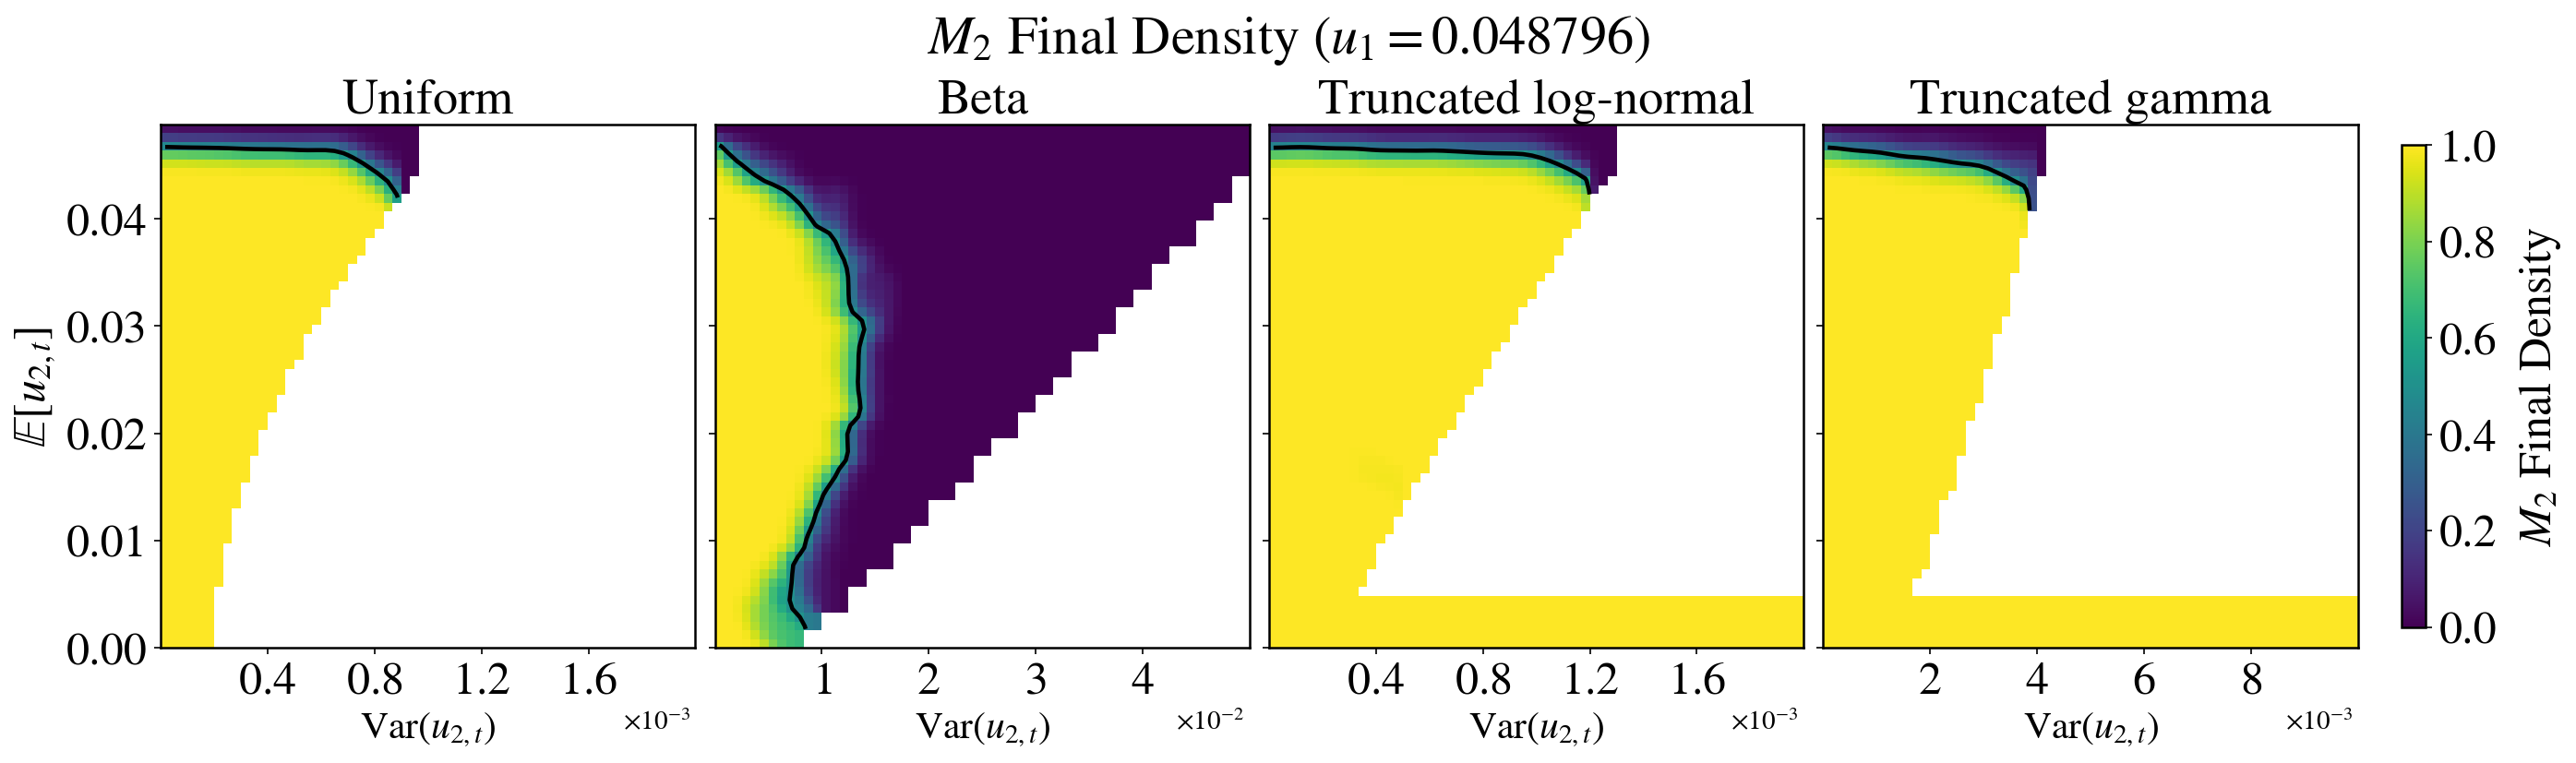

In [52]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, MaxNLocator
from pathlib import Path
from scipy.ndimage import gaussian_filter

# -----------------------------
# FILES / SETTINGS
# -----------------------------
CHOSEN_U1 = 0.048796284095

FILES = {
    "Uniform":              Path("Simulations/s3_uniform_simulation_results.csv"),
    "Beta":                 Path("Simulations/s2_beta_simulation_results.csv"),
    "Truncated log-normal": Path("Simulations/s5_lognorm_simulation_results.csv"),
    "Truncated gamma":      Path("Simulations/s7_gamma_simulation_results.csv"),
}

X_LIMS = {
    "Uniform":              (0, 0.002),
    "Beta":                 (0, 0.05),
    "Truncated log-normal": (0, 0.002),
    "Truncated gamma":      (0, 0.01),
}

X_COL = "var"        # Var(u_{2,t})
Y_COL = "mean"       # E[u_{2,t}]
M2_COL = "M2_final"  # final M2 frequency

# Fixation definition
FIX = 0.99

# Binning + smoothing
NBINS_X = 60
NBINS_Y = 60
SMOOTH_SIGMA = 1.2     # increase to ~1.6–2.0
CONTOUR_LEVEL = 0.5

# Output
# OUTDIR = Path("Figures")
# OUTFILE = OUTDIR / "f2_heatmap_fixprob.png"

# -----------------------------
# Overleaf-friendly fonts
# -----------------------------
plt.rcParams.update({
    "font.size": 24,
    "axes.titlesize": 26,
    "axes.labelsize": 24,
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,
})

# ==========================================================
# Helpers: binned sum + count, then smooth properly
# ==========================================================
def binned_sum_count_2d(x, y, v, x_edges, y_edges):
    x = np.asarray(x); y = np.asarray(y); v = np.asarray(v)

    xi = np.digitize(x, x_edges) - 1
    yi = np.digitize(y, y_edges) - 1

    nx = len(x_edges) - 1
    ny = len(y_edges) - 1

    Vsum = np.zeros((ny, nx), dtype=float)
    Vcnt = np.zeros((ny, nx), dtype=float)

    mask = (xi >= 0) & (xi < nx) & (yi >= 0) & (yi < ny) & np.isfinite(v)
    xi = xi[mask]; yi = yi[mask]; vv = v[mask]

    np.add.at(Vsum, (yi, xi), vv)
    np.add.at(Vcnt, (yi, xi), 1.0)
    return Vsum, Vcnt

def smooth_ratio(Vsum, Vcnt, sigma):
    Ssum = gaussian_filter(Vsum, sigma=sigma, mode="nearest")
    Scnt = gaussian_filter(Vcnt, sigma=sigma, mode="nearest")
    return np.divide(Ssum, Scnt, out=np.full_like(Ssum, np.nan), where=(Scnt > 1e-12))

# ==========================================================
# Load data + validate
# ==========================================================
data = {label: pd.read_csv(path) for label, path in FILES.items()}
for label, df in data.items():
    missing = [c for c in (X_COL, Y_COL, M2_COL) if c not in df.columns]
    if missing:
        raise ValueError(f"[{label}] missing columns {missing}. Available: {list(df.columns)}")

# ==========================================================
# Plot
# ==========================================================
fig, axes = plt.subplots(1, 4, figsize=(18.5, 5.4), sharey=True, constrained_layout=True)

vmin, vmax = 0.0, 1.0
last_pcm = None

for ax, (label, df) in zip(axes, data.items()):
    x = df[X_COL].to_numpy()
    y = df[Y_COL].to_numpy()
    m2 = df[M2_COL].to_numpy()

    # fixation indicator => bin-average is fixation probability
    v = (m2 >= FIX).astype(float)

    x_min, x_max = X_LIMS.get(label, (np.nanmin(x), np.nanmax(x)))
    y_min, y_max = 0.0, CHOSEN_U1

    x_edges = np.linspace(x_min, x_max, NBINS_X + 1)
    y_edges = np.linspace(y_min, y_max, NBINS_Y + 1)

    Vsum, Vcnt = binned_sum_count_2d(x, y, v, x_edges, y_edges)
    Z = smooth_ratio(Vsum, Vcnt, sigma=SMOOTH_SIGMA)

    pcm = ax.pcolormesh(
        x_edges, y_edges, Z,
        cmap="viridis",
        vmin=vmin, vmax=vmax,
        shading="auto"
    )
    last_pcm = pcm

    # 50% fixation contour
    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
    y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])
    Xc, Yc = np.meshgrid(x_centers, y_centers)
    if np.any(np.isfinite(Z)):
        ax.contour(Xc, Yc, Z, levels=[CONTOUR_LEVEL], colors="k", linewidths=2.2)

    # Labels / formatting
    ax.set_title(label)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel(r"$\mathrm{Var}(u_{2,t})$", fontsize=20)
    ax.grid(False)

    # Scientific notation formatting; push offset away from xlabel
    fmt = ScalarFormatter(useMathText=True)
    fmt.set_powerlimits((0, 0))
    ax.xaxis.set_major_formatter(fmt)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5, prune="both"))
    ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

    # Make the ×10^k offset look like a separate scale note, not part of xlabel
    off = ax.xaxis.get_offset_text()
    off.set_size(14)
    off.set_x(0.990)     # right side
    off.set_y(0)    # below ticks, above xlabel
    off.set_ha("right")
    off.set_va("top")

axes[0].set_ylabel(r"$\mathbb{E}[u_{2,t}]$")

fig.suptitle(
    rf"$M_2$ Final Density ($u_1={CHOSEN_U1:.6f}$)",
    fontsize=28
)

# Colorbar: short + rigorous
cbar = fig.colorbar(last_pcm, ax=axes, location="right", shrink=0.92, pad=0.02)
cbar.set_label(r"$M_2$ Final Density", labelpad=10)

# Save
# OUTDIR.mkdir(parents=True, exist_ok=True)
# plt.savefig(OUTFILE, dpi=300)
plt.show()
plt.close()
# print(f"Saved: {OUTFILE}")


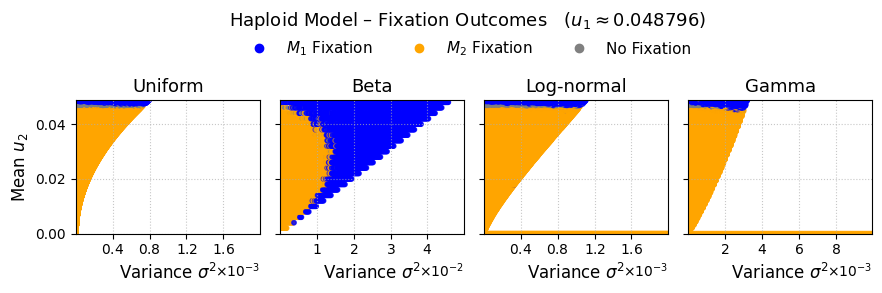

In [210]:
# ---------------------------------------------------------------------------
# Constants / file paths
# ---------------------------------------------------------------------------
CHOSEN_U1 = 0.048796284095
FILES = {
    "Uniform"   : Path("Simulations/s3_uniform_simulation_results.csv"),
    "Beta"      : Path("Simulations/s2_beta_simulation_results.csv"),
    "Log‑normal": Path("Simulations/s5_lognorm_simulation_results.csv"),
    "Gamma"     : Path("Simulations/s7_gamma_simulation_results.csv"),
}

X_LIMS = {
    "Uniform"   : (0, 0.002),
    "Beta"      : (0, 0.05),
    "Log‑normal": (0, 0.002),
    "Gamma"     : (0, 0.01),
}

# -------------------------------------------------
# Load data
# ---------------------------------------------------------------------------
data = {label: pd.read_csv(path) for label, path in FILES.items()}

# ---------------------------------------------------------------------------
# Figure prep
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(10.5, 3.2), sharey=True)

color_map = {'m1': 'blue', 'm2': 'orange', 'none': 'gray'}

for ax, (label, df) in zip(axes, data.items()):
    m2_dom = df["M2_final"] > 0.99
    m1_dom = df["M1_final"] > 0.99
    cat = np.full(len(df), 'none', dtype=object)
    cat[m2_dom.values] = 'm2'
    cat[m1_dom.values] = 'm1'
    colors = [color_map[c] for c in cat]
    sizes = np.where(cat == 'none', 3, 10)  # Smaller dots for "none"

    ax.scatter(df["var"], df["mean"], c=colors, s=sizes, alpha=0.8)

    ax.set_title(label, fontsize=13)
    ax.set_xlabel(r"Variance $\sigma^2$", fontsize=12)
    ax.grid(True, linestyle=":", linewidth=0.8, alpha=0.7)
    ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5, prune="both"))
    ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
    ax.tick_params(axis='both', labelsize=10)

    custom = X_LIMS.get(label)
    if custom is None:
        vmin, vmax = df["var"].min(), df["var"].max()
        pad = 0.1 * (vmax - vmin)
        ax.set_xlim(vmin - pad, vmax + pad)
    else:
        ax.set_xlim(*custom)

axes[0].set_ylabel(r"Mean $u_{2}$", fontsize=12)
axes[0].set_ylim(0, CHOSEN_U1)

# ---------------------------------------------------------------------------
# Global title & legend
# ---------------------------------------------------------------------------
fig.suptitle(
    rf"Haploid Model – Fixation Outcomes   ($u_1 \approx {CHOSEN_U1:.5g}$)",
    fontsize=13,
    y=0.95
)

handles = [
    plt.Line2D([], [], color="blue", marker="o", linestyle="None", label="$M_1$ Fixation"),
    plt.Line2D([], [], color="orange", marker="o", linestyle="None", label="$M_2$ Fixation"),
    plt.Line2D([], [], color="gray", marker="o", linestyle="None", label="No Fixation"),
]

fig.legend(handles=handles,
           loc="upper center",
           bbox_to_anchor=(0.5, 0.90),
           ncol=3,
           frameon=False,
           fontsize=11)

fig.tight_layout(rect=[0.05, 0.05, 0.9, 0.9])
Path("Figures").mkdir(parents=True, exist_ok=True)
plt.savefig("Figures/f2_haploid_simulation_results.png", dpi=300)
plt.show()
plt.close()


# Diploid Population

In [245]:
"""
Diploid two‑locus invasion simulation (Twomey et al. 1990, Eqs 1–4)
==================================================================

* β‑distributed u₂,t with scale MAX_U2
* Resident rate u₁ fixed, mutant rate u₃ ≪ u₁
* Variable recombination fraction R ∈ {0, 0.25, 0.5}

Outputs
-------
• CSV summary table   (final M₁, M₂ for each β‑grid row × R)  
• PNG scatter figure  (colour‑coded fixation outcomes)
"""
# ---------------------------------------------------------------------------
# CONSTANTS (adjust here only)
# ---------------------------------------------------------------------------
chosen_u1  = 0.048796284095         # u_M1M1
chosen_u3  = 0.01       # u_M2M2
MAX_U2     = 0.07        # scale of β draw
generations = 5_000
s           = 0.2
R_values    = [0.0, 0.25, 0.5]
UPPER = 1.0

GRID_CSV = Path("/Users/elisaheinrichmora/Documents/GitHub/Random_Modifier/Simulations/s1_beta_feasibility_grid.csv").expanduser()
OUT_CSV  = Path("/Users/elisaheinrichmora/Documents/GitHub/Random_Modifier/Simulations/s8_beta_diploid_R_results.csv").expanduser()
OUT_FIG  = Path("/Users/elisaheinrichmora/Documents/GitHub/Random_Modifier/Figures/f3_diploid_R_comparison_plot.png").expanduser()

# ---------------------------------------------------------------------------
# Diploid recursion (vectorised over time)
# ---------------------------------------------------------------------------
def diploid_recursion(
    u1: float,
    u3: float,
    u2_series: np.ndarray,           # length = generations
    R: float,
    init_freq: Tuple[float, float, float, float],
    sel: float = s,
) -> Tuple[float, float]:
    """
    One trajectory of the Twomey et al. diploid model.
    Returns final (M1, M2) allele frequencies.
    """
    assert 0 <= R <= 0.5, "Recombination fraction must be in [0,0.5]"
    assert sel <= 0.5, "With sel>0.5, w22 becomes negative."

    x1, x2, x3, x4 = init_freq
    w11, w12, w22  = 1.0, 1.0 - sel, 1.0 - 2 * sel

    for u2 in u2_series:                   # iterate through generations
        # mean fitness
        w_bar = (
            (x1 + x2) ** 2 * w11 +
            2 * w12 * (x1 + x2) * (x3 + x4) +
            (x3 + x4) ** 2 * w22
        )

        D = x1 * x4 - x3 * x2              # linkage disequilibrium

        # haplotype recursions (eqs 1–4, scaled by 1/w_bar)
        x1_new = (
            (1 - u1) * (x1**2 * w11 + x1 * x2 * w12) +
            (1 - u2) * (x1 * x3 * w11 + x1 * x4 * w12 - R * w12 * D)
        ) / w_bar

        x2_new = (
            x2**2 * w22 + x1 * x2 * w12 + x3 * x2 * w12 + x2 * x4 * w22 +
            R * w12 * D +
            u1 * (x1**2 * w11 + x1 * x2 * w12) +
            u2 * (x1 * x3 * w11 + x1 * x4 * w12 - R * w12 * D)
        ) / w_bar

        x3_new = (
            (1 - u3) * (x3**2 * w11 + x3 * x4 * w12) +
            (1 - u2) * (x1 * x3 * w11 + x3 * x2 * w12 + R * w12 * D)
        ) / w_bar

        x4_new = (
            x4**2 * w22 + x1 * x4 * w12 + x3 * x4 * w12 + x2 * x4 * w22
            - R * w12 * D +
            u3 * (x3**2 * w11 + x3 * x4 * w12) +
            u2 * (x1 * x3 * w11 + x3 * x2 * w12 + R * w12 * D)
        ) / w_bar

        # renormalise (guards drift)
        tot = x1_new + x2_new + x3_new + x4_new
        x1, x2, x3, x4 = x1_new / tot, x2_new / tot, x3_new / tot, x4_new / tot

    return x1 + x2, x3 + x4                # allele frequencies M1, M2

# ---------------------------------------------------------------------------
# LOAD β‑GRID
# ---------------------------------------------------------------------------
df_grid = pd.read_csv(GRID_CSV)
df_grid = df_grid[df_grid["beta_feasible"]].reset_index(drop=True)

# ---------------------------------------------------------------------------
# RUN SIMULATIONS
# ---------------------------------------------------------------------------
results = []
rng = np.random.default_rng(42)

for row in tqdm(df_grid.itertuples(index=False),
                total=len(df_grid),
                desc="Simulating β‑grid"):
    alpha, beta_val = row.beta_alpha, row.beta_beta

    # pre‑draw β‑distributed u₂,t once
    u2_series = UPPER * rng.beta(alpha, beta_val, generations)

    # initial haplotype frequencies (tiny M2 intro)
    while True:                             # ensure positivity
        t1, t2 = rng.uniform(0, 0.01, 2)
        if t1 + t2 < 0.24:                  # keeps x2 positive
            break
    init_freq = (0.76 - t1, 0.24 - t2, t1, t2)

    for R in R_values:
        m1, m2 = diploid_recursion(
            chosen_u1, chosen_u3, u2_series, R, init_freq
        )
        results.append((row.mean, row.var, R, m1, m2))

final_df = pd.DataFrame(results,
                        columns=["mean", "var", "R", "M1_final", "M2_final"])
OUT_CSV.parent.mkdir(parents=True, exist_ok=True)
final_df.to_csv(OUT_CSV, index=False)
print(f"✓ Saved summary table → {OUT_CSV}")


Simulating β‑grid: 100%|██████████| 222562/222562 [2:46:14<00:00, 22.31it/s]  


✓ Saved summary table → /Users/elisaheinrichmora/Documents/GitHub/Random_Modifier/Simulations/s8_beta_diploid_R_results.csv


✓ Saved figure       → /Users/elisaheinrichmora/Documents/GitHub/Random_Modifier/Figures/f3_diploid_R_comparison_plot.png


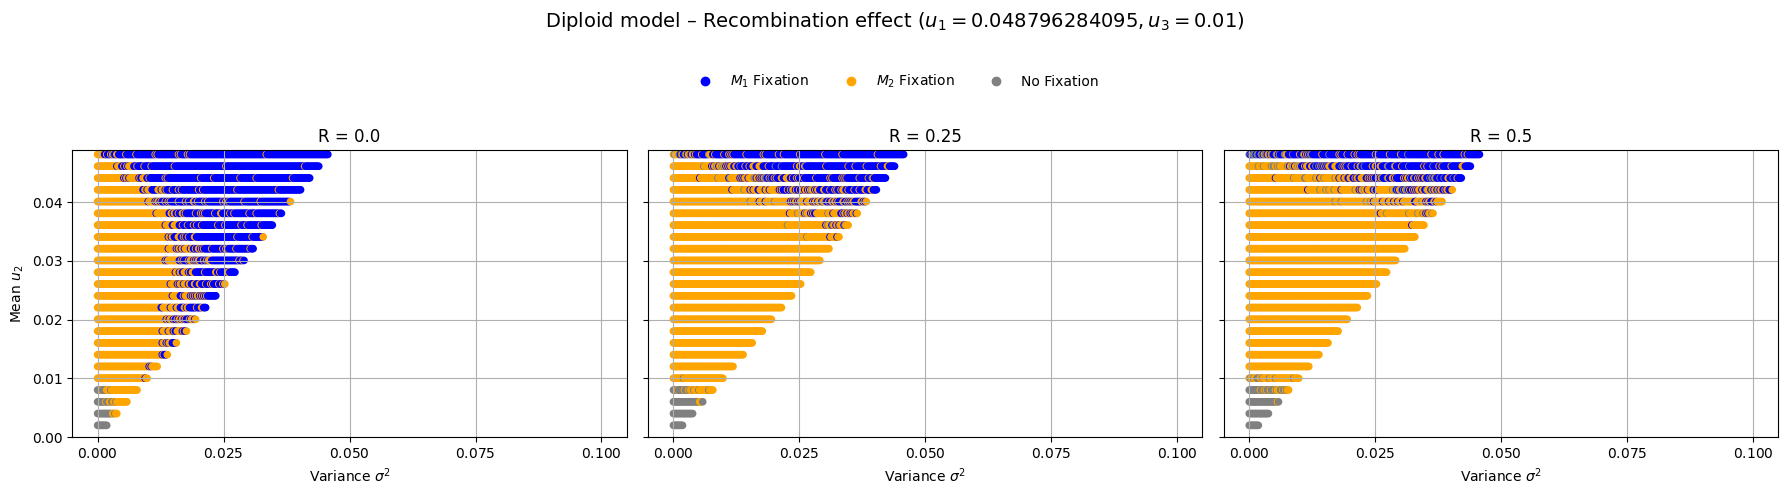

In [246]:
# ---------------------------------------------------------------------------
# PLOT: Single-pass coloring by outcome
# ---------------------------------------------------------------------------
OUT_FIG.parent.mkdir(parents=True, exist_ok=True)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

color_map = {'m1': 'blue', 'm2': 'orange', 'none': 'gray'}

for ax, R in zip(axes, R_values):
    sub = final_df[final_df["R"] == R]
    m2_dom = sub["M2_final"] > 0.98
    m1_dom = sub["M1_final"] > 0.98

    # Assign category string to each point
    cat = np.full(len(sub), 'none', dtype=object)
    cat[m2_dom.values] = 'm2'
    cat[m1_dom.values] = 'm1'

    # Map to color
    colors = [color_map[c] for c in cat]

    # Plot all points in one scatter
    ax.scatter(sub["var"], sub["mean"], c=colors, s=20)

    ax.set_title(f"R = {R}")
    ax.set_xlabel(r"Variance $\sigma^2$")
    ax.grid(True)
    ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5, prune="both"))

    if R == R_values[0]:
        ax.set_ylabel(r"Mean $u_2$")
        ax.set_ylim(0, chosen_u1)

# single legend (matches colors)
handles = [
    plt.Line2D([], [], color="blue", marker="o", linestyle="None", label=r"$M_1$ Fixation"),
    plt.Line2D([], [], color="orange", marker="o", linestyle="None", label=r"$M_2$ Fixation"),
    plt.Line2D([], [], color="gray", marker="o", linestyle="None", label="No Fixation"),
]
fig.legend(handles=handles, loc="upper center",
           bbox_to_anchor=(0.5, 0.88), ncol=3, frameon=False)

fig.suptitle(
    rf"Diploid model – Recombination effect "
    rf"($u_1={chosen_u1},u_3={chosen_u3}$)",
    fontsize=14,
)
fig.tight_layout(rect=[0, 0, 1, 0.85])
fig.savefig(OUT_FIG, dpi=300)
print(f"✓ Saved figure       → {OUT_FIG}")
plt.show()
plt.close()


# Fig. 3: Recombination effect- Stochastic R>0

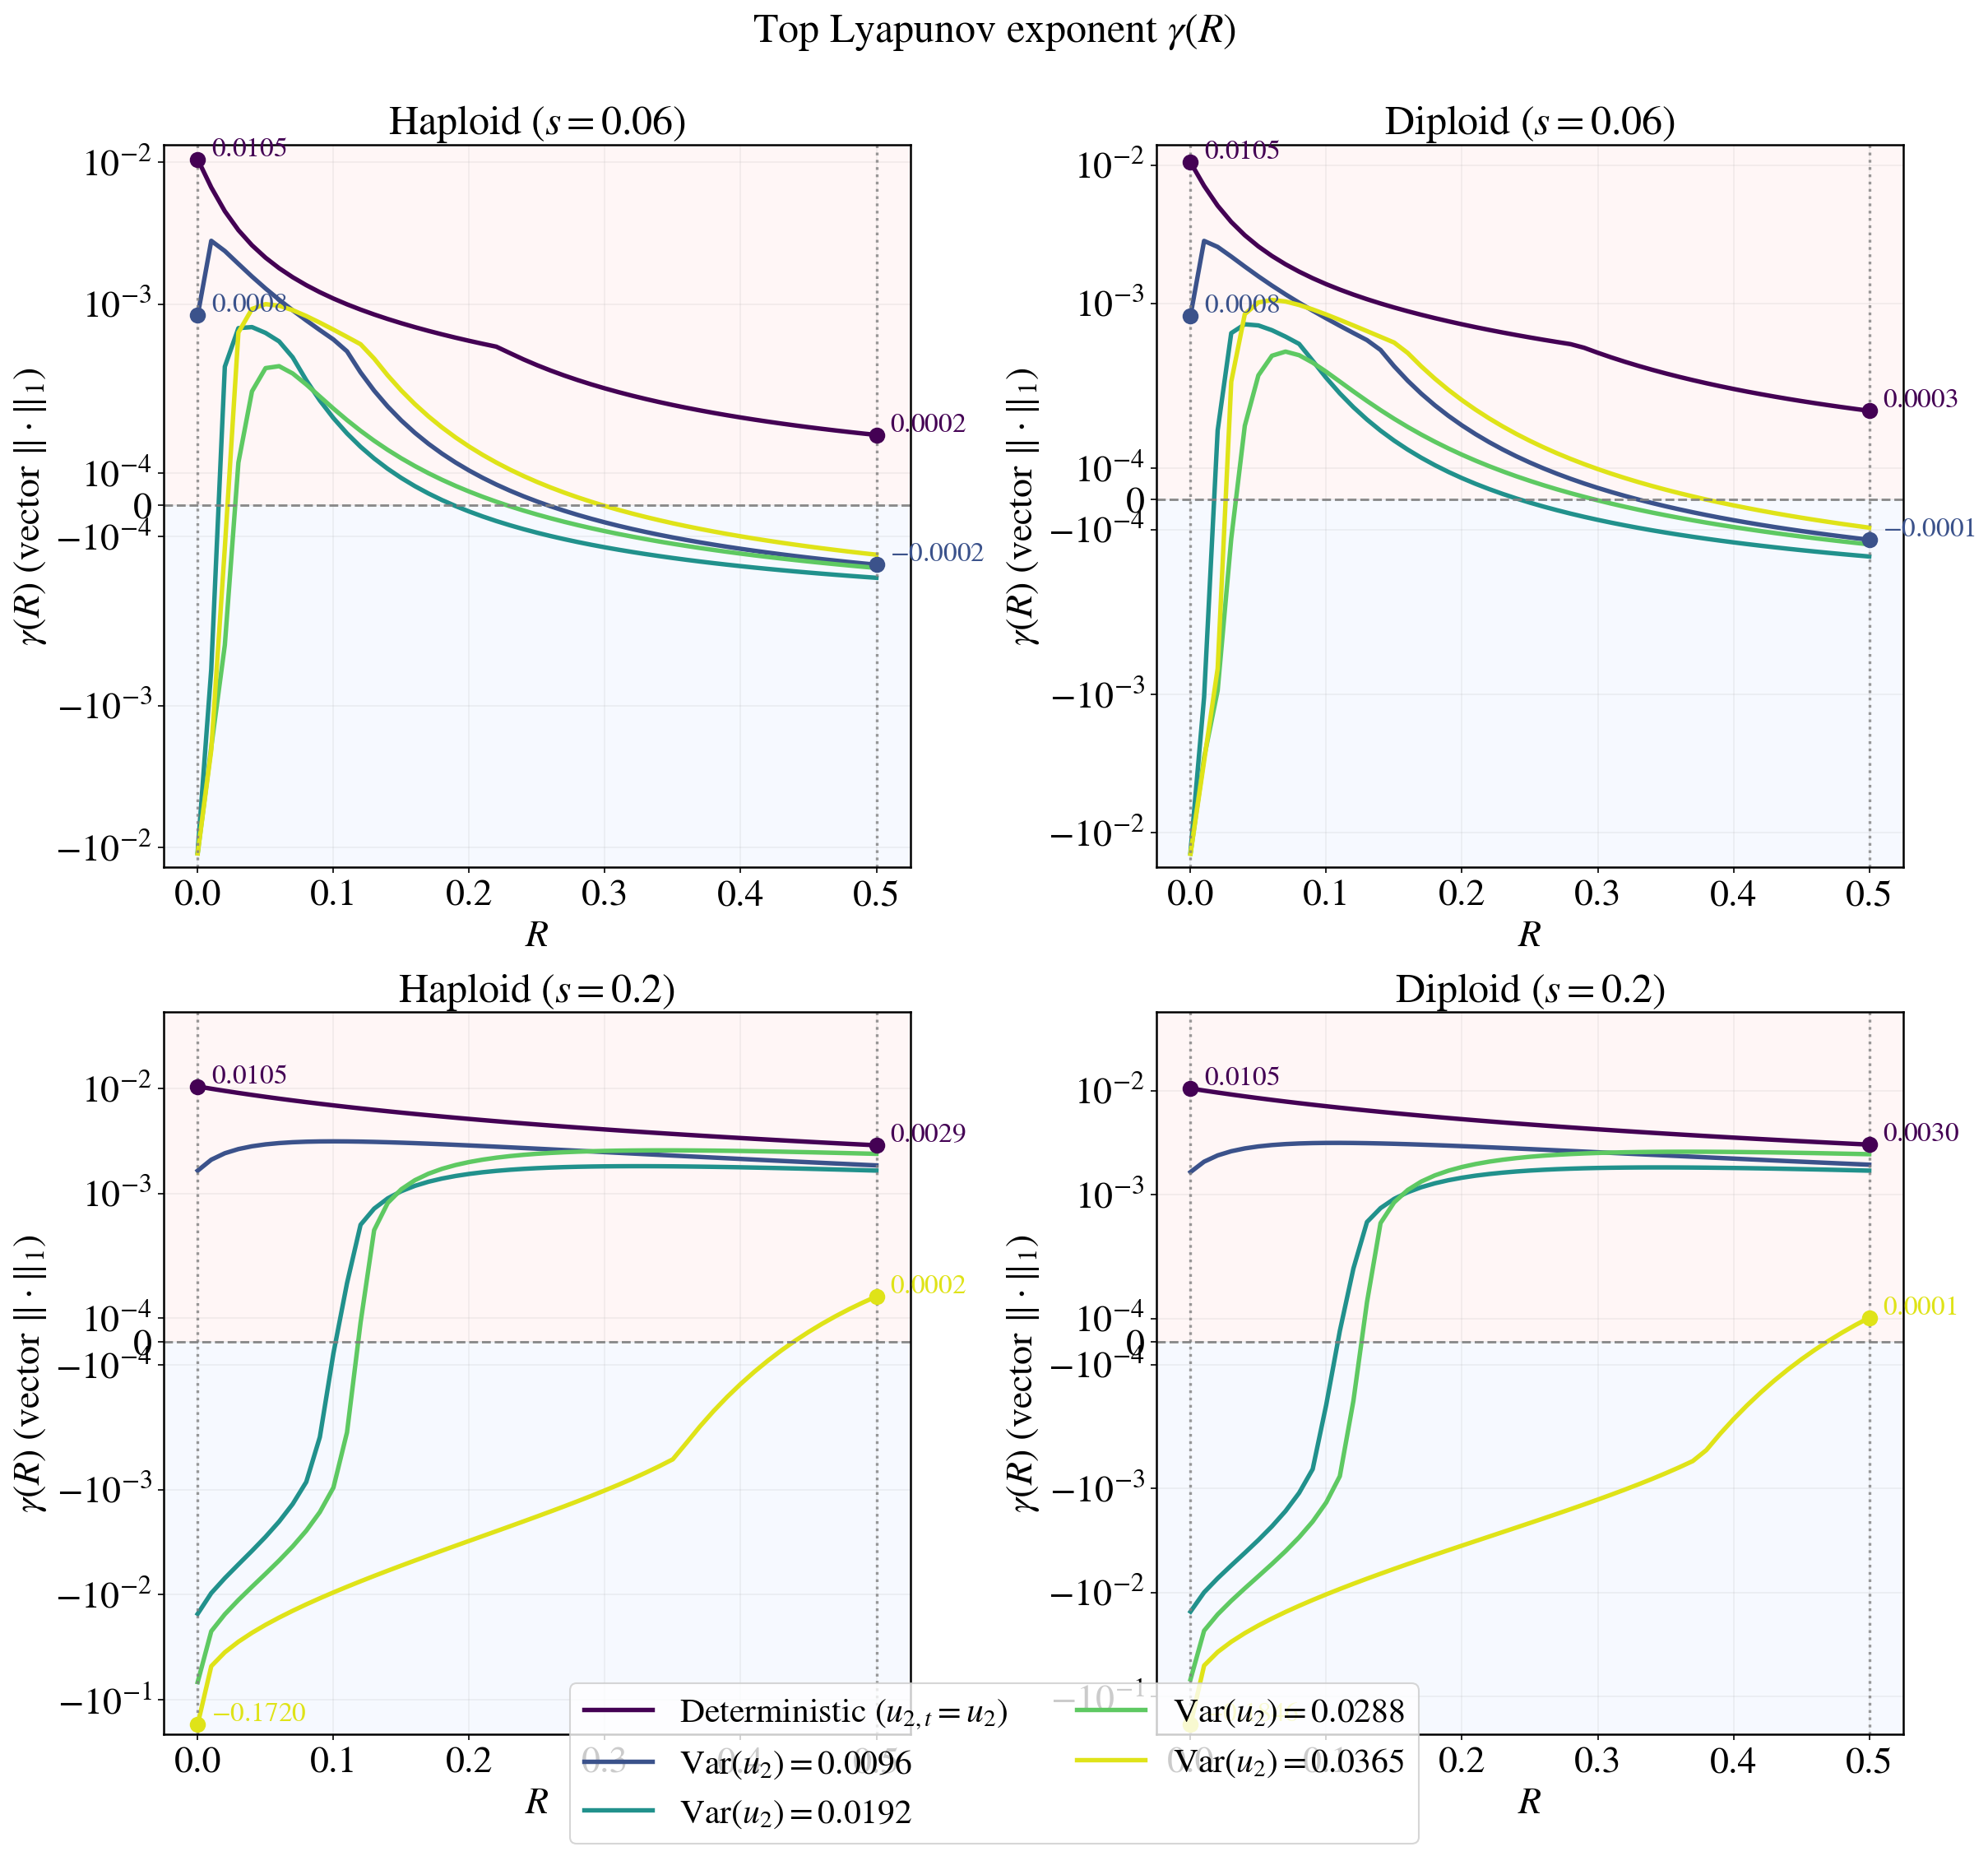

In [47]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from typing import Dict, List, Tuple, Callable

# ============================================================
# Rigorous, publication-style 2×2 figure with:
# - Large scientific suptitle rendered by Matplotlib (mathtext)
# - Larger fonts everywhere
# - Shared legend
# - Same computations + sanity checks at R=0
# - Shaded regions for γ<0 and γ>0
# - Optional point annotations at R=0 and R=1/2 for chosen variances
# ============================================================

# ----------------------------
# Global styling (bigger fonts + scientific math)
# ----------------------------
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 22,
    "axes.titlesize": 24,
    "axes.labelsize": 22,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
    "legend.fontsize": 20,
    "mathtext.fontset": "stix",
    "font.family": "STIXGeneral",
})

# ----------------------------
# Parameters
# ----------------------------
SEED = 20
rng = np.random.default_rng(SEED)

u1 = 0.05
u2_mean = 0.04
S_VALUES = [0.06, 0.20]

T_run = 10_000
R_vals = np.linspace(0.0, 0.5, 51)

ONE_MINUS_EPS = np.nextafter(1.0, 0.0)

SUPTITLE = (
    r"Top Lyapunov exponent $\gamma(R)$"
)

# Variance levels (fractions of max variance) used throughout
VAR_FRACS = [0.0, 0.25, 0.50, 0.75, 0.95]

# Symlog threshold used for y-axis
SYMLINTHRESH = 5e-4

# Sanity tolerance (as in your original)
SANITY_TOL = 1.7e-2


# ----------------------------
# Helpers: Beta parameterization
# ----------------------------
def beta_params_from_mean_var(m: float, v: float) -> Tuple[float, float]:
    """
    Return (a,b) such that Beta(a,b) has mean m and variance v (clipped to feasible range).
    If v<=0, returns (inf,inf) meaning "deterministic at mean".
    """
    if not (0.0 < m < 1.0):
        raise ValueError("mean m must be in (0,1)")
    if v <= 0.0:
        return np.inf, np.inf
    v_max = m * (1.0 - m)
    # Keep v in (0, v_max) to avoid degeneracy
    v = min(max(v, v_max * 1e-12), v_max * (1.0 - 1e-12))
    denom = m * (1.0 - m) / v - 1.0
    if denom <= 0.0:
        denom = 1e-9
    return m * denom, (1.0 - m) * denom


def generate_u2_series(mean: float, var: float, T: int, rng: np.random.Generator) -> np.ndarray:
    a, b = beta_params_from_mean_var(mean, var)
    if np.isinf(a):
        x = np.full(T, mean, dtype=float)
    else:
        x = rng.beta(a, b, size=T).astype(float)
    return np.clip(x, 0.0, ONE_MINUS_EPS)


# ----------------------------
# Matrix builders
# ----------------------------
def F_hap(u1: float, u2t: float, s: float, R: float) -> np.ndarray:
    denom = (1.0 - u1)
    one_minus_s = (1.0 - s)
    A = (1.0 - u2t)
    factor = (R * one_minus_s) / (s * denom)
    a11 = A * (1.0 - u1 * factor)
    a12 = A * ((s - u1) * factor)
    a21 = u2t + A * (u1 * factor)
    a22 = one_minus_s - A * ((s - u1) * factor)
    return (1.0 / denom) * np.array([[a11, a12], [a21, a22]], float)


def F_dip(u1: float, u2t: float, s: float, R: float) -> np.ndarray:
    denom = (1.0 - u1) * s
    one_minus_s = (1.0 - s)
    a11 = (1.0 - u2t) * (s - u1 * R * one_minus_s)
    a12 = (1.0 - u2t) * one_minus_s * R * (s - u1 * one_minus_s)
    a21 = u1 * one_minus_s * R + u2t * (s - u1 * R * one_minus_s)
    a22 = (one_minus_s
           * ((1.0 - R) + u2t * R) * (s - u1 * one_minus_s)
           + (1.0 - 2.0 * s) * u1)
    return (1.0 / denom) * np.array([[a11, a12], [a21, a22]], float)


# ----------------------------
# Lyapunov / gamma computations
# ----------------------------
def lyap_1norm(F_builder: Callable[[float, float, float, float], np.ndarray],
               u2_series: np.ndarray, R: float, u1: float, s: float) -> float:
    v = np.array([0.01, 0.01], float)
    logs = 0.0
    for u2t in u2_series:
        v = F_builder(u1, u2t, s, R) @ v
        nv = float(np.sum(np.abs(v)))
        if not np.isfinite(nv) or nv <= 0.0:
            nv = 1e-300
        logs += np.log(nv)
        v /= nv
    return logs / len(u2_series)


def gamma_det(F_builder: Callable[[float, float, float, float], np.ndarray],
              u1: float, u2_mean: float, s: float, R: float) -> float:
    M = F_builder(u1, u2_mean, s, R)
    return float(np.log(np.max(np.abs(np.linalg.eigvals(M)))))


def gamma0_hap_analytic(u1: float, s: float, u2_series: np.ndarray) -> float:
    return max(np.mean(np.log(1.0 - u2_series)) - np.log(1.0 - u1),
               np.log(1.0 - s) - np.log(1.0 - u1))


def gamma0_dip_analytic(u1: float, s: float, u2_series: np.ndarray) -> float:
    term1 = np.mean(np.log(1.0 - u2_series)) - np.log(1.0 - u1)
    d2 = ((1.0 - s) * (s - u1 * (1.0 - s)) + (1.0 - 2.0 * s) * u1) / ((1.0 - u1) * s)
    return max(term1, np.log(d2))


# ----------------------------
# Curve computation per s
# ----------------------------
def compute_curves_for_s(s: float):
    max_var = u2_mean * (1.0 - u2_mean)
    var_levels = [frac * max_var for frac in VAR_FRACS]

    # Generate u2 time series per variance once (reused for all R)
    u2_series_by_var = {v: generate_u2_series(u2_mean, v, T_run, rng) for v in var_levels}

    # Sanity/consistency checks at R = 0.0
    for v, series in u2_series_by_var.items():
        g0h = lyap_1norm(F_hap, series, 0.0, u1, s)
        g0d = lyap_1norm(F_dip, series, 0.0, u1, s)
        assert abs(g0h - gamma0_hap_analytic(u1, s, series)) < SANITY_TOL
        assert abs(g0d - gamma0_dip_analytic(u1, s, series)) < SANITY_TOL

    results_hap: Dict[float, List[Tuple[float, float]]] = {}
    results_dip: Dict[float, List[Tuple[float, float]]] = {}

    for v, series in u2_series_by_var.items():
        if v == 0.0:
            hap_curve = [(R, gamma_det(F_hap, u1, u2_mean, s, R)) for R in R_vals]
            dip_curve = [(R, gamma_det(F_dip, u1, u2_mean, s, R)) for R in R_vals]
        else:
            hap_curve = [(R, lyap_1norm(F_hap, series, R, u1, s)) for R in R_vals]
            dip_curve = [(R, lyap_1norm(F_dip, series, R, u1, s)) for R in R_vals]

        results_hap[v] = hap_curve
        results_dip[v] = dip_curve

    return results_hap, results_dip, max_var


# ----------------------------
# Plot utilities
# ----------------------------
def label_for_var(v: float) -> str:
    if v == 0.0:
        return r"Deterministic ($u_{2,t}=u_2$)"
    return rf"$\operatorname{{Var}}(u_2)= {v:.3g}$"


def add_shading_and_refs(ax: plt.Axes, y_min: float, y_max: float):
    """
    Background shading for γ<0 and γ>0 + reference lines.
    """
    pad = 0.25 * max(abs(y_min), abs(y_max), 1e-6)
    ax.axhspan(y_min - pad, 0.0, facecolor="#e6f0ff", alpha=0.35, zorder=0)
    ax.axhspan(0.0, y_max + pad, facecolor="#ffe6e6", alpha=0.35, zorder=0)

    ax.axvline(0.0, linestyle=":", linewidth=1.6, alpha=0.8, color="gray")
    ax.axvline(0.5, linestyle=":", linewidth=1.6, alpha=0.8, color="gray")
    ax.axhline(0.0, linestyle="--", linewidth=1.4, alpha=0.9, color="gray")

    ax.set_yscale("symlog", linthresh=SYMLINTHRESH, linscale=1.0, base=10)
    ax.set_ylim(y_min - pad, y_max + pad)
    ax.grid(alpha=0.18)


def plot_panel(ax: plt.Axes,
               results: Dict[float, List[Tuple[float, float]]],
               max_var: float,
               title: str,
               annotate_vars: List[float],
               cmap=cm.viridis,
               capture_handles: bool = False):
    """
    Plot one panel. Returns legend handles (only if capture_handles True).
    """
    handles = []
    items = sorted(results.items(), key=lambda kv: kv[0])
    denom = max_var if max_var > 0 else 1.0

    # Track y-range for shading/limits
    y_all: List[float] = []

    for v, curve in items:
        Rs = np.fromiter((x for x, _ in curve), dtype=float)
        Gs = np.fromiter((y for _, y in curve), dtype=float)
        y_all.extend(Gs.tolist())

        t = v / denom
        color = cmap(t)

        ln, = ax.plot(Rs, Gs, linewidth=2.6, color=color, label=label_for_var(v))
        if capture_handles:
            handles.append(ln)

        # Point annotation at R=0 and R=1/2 for specified variances
        if any(np.isclose(v, tgt, rtol=0.0, atol=1e-12) for tgt in annotate_vars):
            gR0 = float(Gs[0])
            gRhalf = float(Gs[-1])
            ax.scatter([0.0, 0.5], [gR0, gRhalf], s=70, color=color, zorder=6)

            # annotate near points
            ax.annotate(rf"${gR0:.4f}$", (0.0, gR0),
                        textcoords="offset points", xytext=(8, 2),
                        fontsize=16, color=color)
            ax.annotate(rf"${gRhalf:.4f}$", (0.5, gRhalf),
                        textcoords="offset points", xytext=(8, 2),
                        fontsize=16, color=color)

    y_min, y_max = float(np.min(y_all)), float(np.max(y_all))
    add_shading_and_refs(ax, y_min, y_max)

    ax.set_title(title)
    ax.set_xlabel(r"$R$")
    ax.set_ylabel(r"$\gamma(R)$ (vector $\|\cdot\|_1$)")

    return handles


# ----------------------------
# Main: compute and plot 2×2 with shared legend + large math suptitle
# ----------------------------
fig, axs = plt.subplots(2, 2, figsize=(16, 14), constrained_layout=True)

shared_legend_handles = None

for i, s in enumerate(S_VALUES):
    res_hap, res_dip, vmax = compute_curves_for_s(s)

    # Match your original annotation logic:
    if np.isclose(s, 0.06):
        annotate_list = [0.0, 0.25 * vmax]
    else:
        annotate_list = [0.0, 0.95 * vmax]

    # Row i, col 0: haploid
    h0 = plot_panel(
        axs[i, 0],
        res_hap,
        vmax,
        title=rf"Haploid ($s={s}$)",
        annotate_vars=annotate_list,
        capture_handles=(i == 0),
    )

    # Row i, col 1: diploid
    _ = plot_panel(
        axs[i, 1],
        res_dip,
        vmax,
        title=rf"Diploid ($s={s}$)",
        annotate_vars=annotate_list,
        capture_handles=False,
    )

    if i == 0:
        shared_legend_handles = h0

# Shared legend (use the labels from the first panel)
if shared_legend_handles is None:
    shared_legend_handles = []

fig.legend(
    handles=shared_legend_handles,
    labels=[h.get_label() for h in shared_legend_handles],
    loc="lower center",
    ncol=2,
    frameon=True,
    bbox_to_anchor=(0.5, -0.02),
)

# Large scientific suptitle (mathtext)
fig.suptitle(SUPTITLE, fontsize=24, y=1.05)

plt.show()

# To save (uncomment):
# fig.savefig("gamma_panels_scientific.png", bbox_inches="tight")


# Fig. 5: Lyapunov Estimations for Haploid Case

/var/folders/hq/r86tzvxd5tq_xy1zy8wl3cxw0000gn/T/ipykernel_24224/2375339190.py:49: RuntimeWarning: divide by zero encountered in log
  return np.nan if u.size < 10 else float(np.mean(np.log(1 - u)))


Figure saved


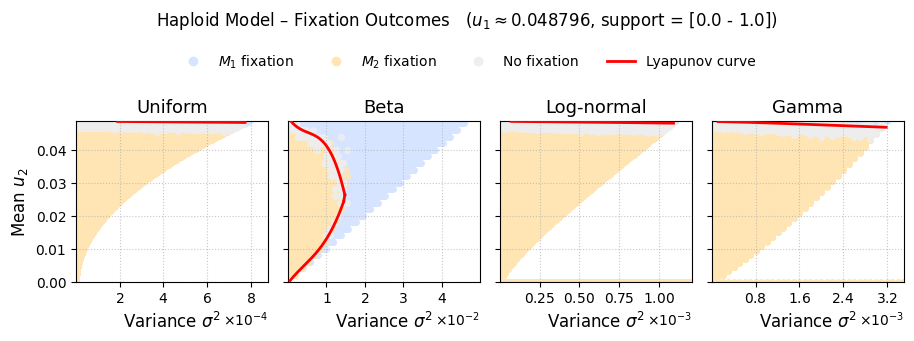

In [6]:

from __future__ import annotations
import argparse, sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MaxNLocator, ScalarFormatter
from scipy.integrate import quad
from scipy.interpolate import UnivariateSpline
from scipy.optimize import brentq
from scipy.stats import beta as beta_dist, gamma as gamma_dist, lognorm

# ---------------------------------------------------------------------------#
# PARAMETERS & PATHS                                                         #
# ---------------------------------------------------------------------------#
SUPPORT   = 1.0
CHOSEN_U1 = 0.048796284095          # resident mean

FILES = {
    "Uniform":    Path("Simulations/s3_uniform_simulation_results.csv"),
    "Beta":       Path("Simulations/s2_beta_simulation_results.csv"),
    "Log-normal": Path("Simulations/s5_lognorm_simulation_results.csv"),
    "Gamma":      Path("Simulations/s7_gamma_simulation_results.csv"),
}

COLORS = {"m1": "#d6e4ff", "m2": "#ffe5b3", "none": "#eeeeee"}

VAR_LIMITS = {
    "Uniform":    (0, 0.8e-3),
    "Beta":       (0, 0.0148),
    "Log-normal": (0, 0.0011),
    "Gamma":      (0, 0.0032),
}

# ---------------------------------------------------------------------------#
# UTILITY FUNCTIONS                                                          #
# ---------------------------------------------------------------------------#
def scatter_outcomes(ax, df: pd.DataFrame) -> None:
    """Plot fixation outcomes coloured by which allele fixed."""
    m2 = df["M2_final"] > 0.99
    m1 = df["M1_final"] > 0.99
    ax.scatter(df.loc[m1, "var"], df.loc[m1, "mean"], color=COLORS["m1"], s=16, alpha=0.9)
    ax.scatter(df.loc[m2, "var"], df.loc[m2, "mean"], color=COLORS["m2"], s=16, alpha=0.9)
    ax.scatter(df.loc[~(m1 | m2), "var"], df.loc[~(m1 | m2), "mean"],
               color=COLORS["none"], s=16, alpha=0.9)

def log_1_minus_u_from_samples(u: np.ndarray, *, support: float = SUPPORT) -> float:
    u = u[(u >= 0) & (u <= 1)] * support
    return np.nan if u.size < 10 else float(np.mean(np.log(1 - u)))

# ---- E[log(1-U)] for each family ----------------------------------------- #
def uniform_log_expectation(mean, var, *, support=SUPPORT):
    k = np.sqrt(3 * var)
    a, b = mean - k, mean + k
    if a < 0 or b > support or a >= b:
        return np.nan
    integral, _ = quad(lambda x: np.log(1 - x), a, b)
    return integral / (b - a)

def beta_log_expectation(mean, var, *, support=SUPPORT, size=20_000):
    m, v = mean / support, var / support**2
    if v <= 0 or m <= 0 or m >= 1:
        return np.nan
    tmp = m * (1 - m) / v - 1
    a, b = m * tmp, (1 - m) * tmp
    if a <= 0 or b <= 0:
        return np.nan
    u = beta_dist.rvs(a, b, size=size)
    return log_1_minus_u_from_samples(u, support=support)

def lognorm_log_expectation(mean, var, *, support=SUPPORT, size=20_000):
    if mean <= 0 or var <= 0:
        return np.nan
    phi2   = var + mean**2
    sigma2 = np.log(phi2 / mean**2)
    mu     = np.log(mean) - 0.5 * sigma2
    u      = lognorm.rvs(np.sqrt(sigma2), scale=np.exp(mu), size=size)
    return log_1_minus_u_from_samples(u, support=support)

def gamma_log_expectation(mean, var, *, support=SUPPORT, size=20_000):
    if mean <= 0 or var <= 0:
        return np.nan
    shape = mean**2 / var
    scale = var / mean
    u     = gamma_dist.rvs(shape, scale=scale, size=size)
    return log_1_minus_u_from_samples(u, support=support)

# ---- root finder ---------------------------------------------------------- #
def critical_means(expect_fn, var, u1, mean_range, *, support=SUPPORT, resolution=100):
    """Return all means where E[log(1-U)]=log(1-u1) for a fixed variance."""
    target  = np.log(1 - u1)
    means   = np.linspace(*mean_range, resolution)
    vals    = [expect_fn(m, var, support=support) for m in means]
    roots   = []
    for i in range(len(means) - 1):
        if np.isnan(vals[i]) or np.isnan(vals[i + 1]):
            continue
        if (vals[i] - target) * (vals[i + 1] - target) < 0:
            try:
                root = brentq(lambda m: expect_fn(m, var, support=support) - target,
                              means[i], means[i + 1])
                roots.append(root)
            except ValueError:
                pass
    return roots

# ---------------------------------------------------------------------------#
# MAIN                                                                        #
# ---------------------------------------------------------------------------#
def build_arg_parser() -> argparse.ArgumentParser:
    p = argparse.ArgumentParser(add_help=False)
    p.add_argument("--s", type=float, default=1.2*1e-3,
                   help="smoothing factor for cubic spline (default 1e‑3)")
    p.add_argument("--save", metavar="OUTFILE",
                   help="write figure to file as well as showing it")
    return p

def main(argv: list[str] | None = None) -> None:
    args, _ = build_arg_parser().parse_known_args(argv or sys.argv[1:])

    # Load data --------------------------------------------------------
    data = {lbl: pd.read_csv(path) for lbl, path in FILES.items()}

    # Compute Lyapunov critical points --------------------------------
    crit = {}
    n_grid = 500
    for lbl in FILES:
        vmin, vmax = VAR_LIMITS[lbl]
        v_grid = np.linspace(vmin, vmax, n_grid)
        v_pts, m_pts = [], []
        for v in v_grid:
            if lbl == "Uniform":
                roots = critical_means(uniform_log_expectation, v, CHOSEN_U1, (1e-4, CHOSEN_U1-1e-4))
            elif lbl == "Beta":
                roots = critical_means(beta_log_expectation,    v, CHOSEN_U1, (1e-4, CHOSEN_U1-1e-4))
            elif lbl == "Log-normal":
                roots = critical_means(lognorm_log_expectation, v, CHOSEN_U1, (1e-4, CHOSEN_U1-1e-4))
            else:
                roots = critical_means(gamma_log_expectation,   v, CHOSEN_U1, (1e-4, CHOSEN_U1-1e-4))
            for r in roots:
                v_pts.append(v)
                m_pts.append(r)
        crit[lbl] = (np.asarray(v_pts), np.asarray(m_pts))

    # Plot -------------------------------------------------------------
    fig, axes = plt.subplots(1, 4, figsize=(10.5, 3.4), sharey=True)

    for ax, lbl in zip(axes, FILES):
        scatter_outcomes(ax, data[lbl])

        # raw critical roots
        v_raw, m_raw = crit[lbl]

        # stats per unique variance (for ±1 σ ribbon) ------------------
        df_stats = (
            pd.DataFrame({"v": v_raw, "m": m_raw})
            .groupby("v", sort=True)["m"]
            .agg(["mean", "std"])
            .reset_index()
            .fillna(0.0)          # std = 0 if only 1 root at that v
        )
        v_u   = df_stats["v"].values
        m_avg = df_stats["mean"].values
        m_std = df_stats["std"].values

        # decide if Beta gets split into two branches ------------------
        if lbl == "Beta":
            mid = (m_raw.max() + m_raw.min()) / 2
            # Get indices sorted by distance to midpoint
            idx_sorted = np.argsort(np.abs(m_raw - mid))
            shared_idx = idx_sorted[:10]  # 5 closest points to midpoint

            # create mask arrays
            is_lower = m_raw < mid
            is_upper = m_raw >= mid

            # force inclusion of shared points in both branches
            include_shared = np.zeros_like(m_raw, dtype=bool)
            include_shared[shared_idx] = True

            # lower branch: lower + shared
            lower_mask = is_lower | include_shared
            upper_mask = is_upper | include_shared

            branches = [
                (v_raw[lower_mask], m_raw[lower_mask]),
                (v_raw[upper_mask], m_raw[upper_mask]),
            ]
        else:
            branches = [(v_raw, m_raw)]

        spline_end_pts = []      # to bridge Beta halves later

        # fit spline(s) ------------------------------------------------
        for v_b, m_b in branches:
            if len(v_b) < 4:
                continue
            # remove duplicate σ² (needed for UnivariateSpline)
            v_unique, idx = np.unique(v_b, return_index=True)
            m_unique      = m_b[idx]
            order         = np.argsort(v_unique)
            spl           = UnivariateSpline(v_unique[order], m_unique[order], s=args.s)

            v_fine = np.linspace(v_unique.min(), v_unique.max(), 1000)
            m_fine = spl(v_fine)
            ax.plot(v_fine, m_fine, lw=2, color="red", zorder=3)

            # store end‑point (largest σ²) to connect Beta halves
            if lbl == "Beta":
                v_max = v_unique.max()
                spline_end_pts.append((v_max, spl(v_max)))

        # bridge Beta halves ------------------------------------------
        if lbl == "Beta" and len(spline_end_pts) == 2:
            (v1, m1), (v2, m2) = sorted(spline_end_pts, key=lambda t: t[0])
            ax.plot([v1, v2], [m1, m2], lw=2, color="red", zorder=3)

        # uncertainty ribbon ±1 σ -------------------------------------
        if len(v_u) > 3:
            interp_mean = UnivariateSpline(v_u, m_avg, s=0)
            interp_std  = UnivariateSpline(v_u, m_std, s=0)

            # v_shade = np.linspace(v_u.min(), v_u.max(), 800)
            # m_mu    = interp_mean(v_shade)
            # m_hi    = m_mu + interp_std(v_shade)
            # m_lo    = m_mu - interp_std(v_shade)

            # ax.fill_between(v_shade, m_lo, m_hi, color="red", alpha=0.20, zorder=2)

        # cosmetics ----------------------------------------------------
        ax.set_title(lbl, fontsize=13)
        ax.set_xlabel(r"Variance $\sigma^2$", fontsize=12)
        vmin, vmax = VAR_LIMITS[lbl]
        
        if lbl == "Beta":  # Beta has two branches, so we set limits manually
            ax.set_xlim(0, 0.050)
        else:
            ax.set_xlim(vmin, vmax + 0.1 * (vmax - vmin))
        ax.set_ylim(0, max(data[lbl]["mean"].max(), CHOSEN_U1))
        ax.grid(True, linestyle=":", linewidth=0.8, alpha=0.7)
        ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5, prune="both"))
        ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
        ax.tick_params(axis="both", labelsize=10)

    axes[0].set_ylabel(r"Mean $u_{2}$", fontsize=12)

    # ----------------------------------------------------------------
    fig.suptitle(
        rf"Haploid Model – Fixation Outcomes   "
        rf"($u_1 \approx {CHOSEN_U1:.5g}$, support = [0.0 - {SUPPORT}])",
        fontsize=12, y=1.04,
    )
    fig.legend(
        handles=[
            plt.Line2D([], [], color=COLORS["m1"], marker="o", linestyle="None", label="$M_1$ fixation"),
            plt.Line2D([], [], color=COLORS["m2"], marker="o", linestyle="None", label="$M_2$ fixation"),
            plt.Line2D([], [], color=COLORS["none"], marker="o", linestyle="None", label="No fixation"),
            plt.Line2D([], [], color="red", lw=2, label=r"Lyapunov curve"),
        ],
        loc="upper center", bbox_to_anchor=(0.5, 0.95), ncol=5, frameon=False, fontsize=10,
    )
    fig.tight_layout(rect=[0.05, 0.05, 0.93, 0.93])

    # save if asked ---------------------------------------------------

    fig.savefig("/Users/elisaheinrichmora/Documents/GitHub/Random_Modifier/Figures/f4_lyapunov_approx.png", dpi=300)
    print(f"Figure saved")


    plt.show()

# ---------------------------------------------------------------------------#
if __name__ == "__main__":
    main()


/var/folders/hq/r86tzvxd5tq_xy1zy8wl3cxw0000gn/T/ipykernel_44447/3542442779.py:113: RuntimeWarning: divide by zero encountered in log
  return np.nan if u.size < 10 else float(np.mean(np.log(1 - u)))


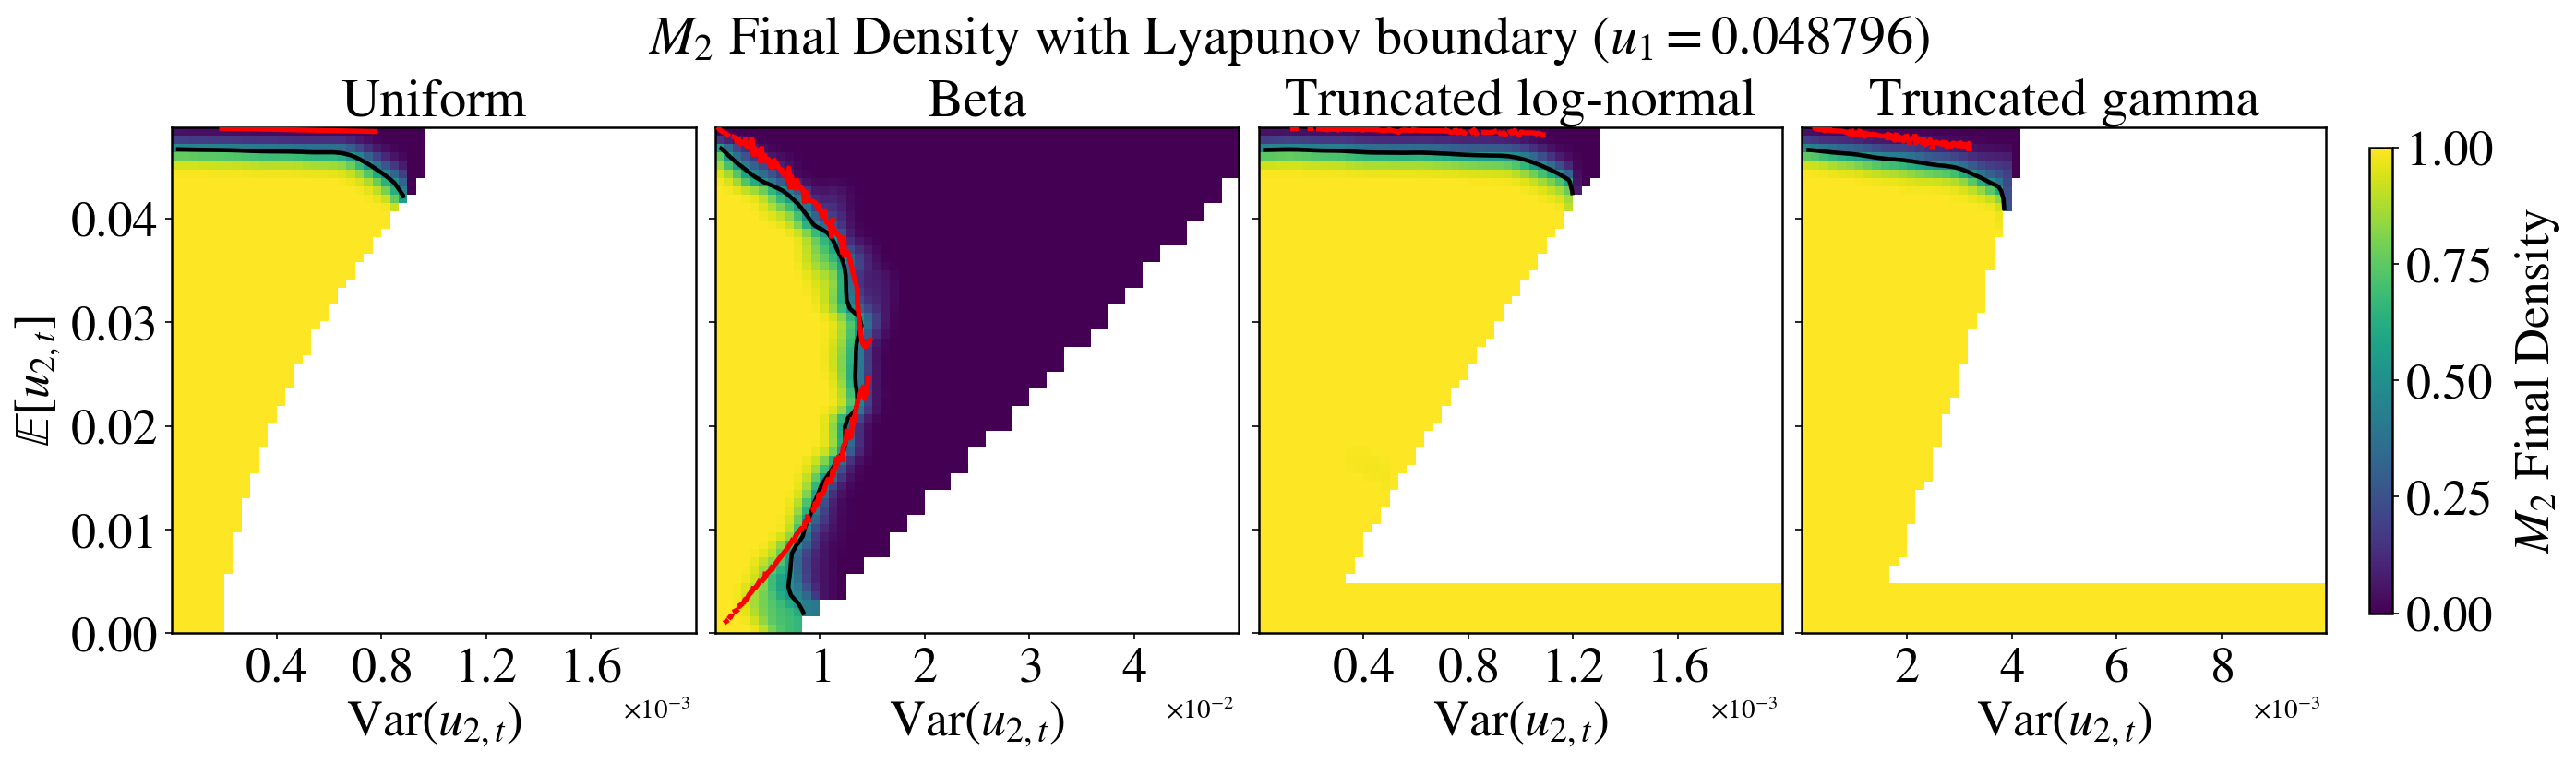

In [51]:
# ==========================================================
# Heatmaps of fixation probability with Lyapunov boundary
# ==========================================================

from __future__ import annotations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, MaxNLocator
from scipy.ndimage import gaussian_filter
from scipy.integrate import quad
from scipy.interpolate import UnivariateSpline
from scipy.optimize import brentq
from scipy.stats import beta as beta_dist, gamma as gamma_dist, lognorm

# -----------------------------
# GLOBALS
# -----------------------------
SUPPORT   = 1.0
CHOSEN_U1 = 0.048796284095

FILES = {
    "Uniform":              Path("Simulations/s3_uniform_simulation_results.csv"),
    "Beta":                 Path("Simulations/s2_beta_simulation_results.csv"),
    "Truncated log-normal": Path("Simulations/s5_lognorm_simulation_results.csv"),
    "Truncated gamma":      Path("Simulations/s7_gamma_simulation_results.csv"),
}

# Heatmap display range
X_LIMS = {
    "Uniform":              (0.0, 0.002),
    "Beta":                 (0.0, 0.05),
    "Truncated log-normal": (0.0, 0.002),
    "Truncated gamma":      (0.0, 0.01),
}

# σ² grid used to compute Lyapunov boundary (keep as in your reference)
VAR_LIMITS = {
    "Uniform":              (0.0, 0.8e-3),
    "Beta":                 (0.0, 0.0148),
    "Truncated log-normal": (0.0, 0.0011),
    "Truncated gamma":      (0.0, 0.0032),
}

X_COL  = "var"        # Var(u_{2,t})
Y_COL  = "mean"       # E[u_{2,t}]
M2_COL = "M2_final"   # final M2 frequency

FIX = 0.99

# Heatmap binning + smoothing
NBINS_X       = 60
NBINS_Y       = 60
SMOOTH_SIGMA  = 1.2
CONTOUR_LEVEL = 0.5

# Lyapunov curve computation
N_GRID_VAR     = 500
MEAN_RANGE     = (1e-4, CHOSEN_U1 - 1e-4)
SCAN_RES       = 100
MC_SIZE        = 20_000  # match your reference
SPLINE_S       = 1.2e-3  # match your reference default
MIN_PTS_SPLINE = 4

# Segment splitting: do NOT spline across gaps (infeasible σ² intervals)
GAP_FACTOR = 3.0  # gap > GAP_FACTOR * Δσ² is considered a break

# -----------------------------
# Overleaf-friendly fonts
# -----------------------------
plt.rcParams.update({
    "font.size": 26,
    "axes.titlesize": 28,
    "axes.labelsize": 26,
    "xtick.labelsize": 26,
    "ytick.labelsize": 26,
})

# ==========================================================
# Heatmap helpers
# ==========================================================
def binned_sum_count_2d(x, y, v, x_edges, y_edges):
    x = np.asarray(x); y = np.asarray(y); v = np.asarray(v)

    xi = np.digitize(x, x_edges) - 1
    yi = np.digitize(y, y_edges) - 1

    nx = len(x_edges) - 1
    ny = len(y_edges) - 1

    Vsum = np.zeros((ny, nx), dtype=float)
    Vcnt = np.zeros((ny, nx), dtype=float)

    mask = (xi >= 0) & (xi < nx) & (yi >= 0) & (yi < ny) & np.isfinite(v)
    xi = xi[mask]; yi = yi[mask]; vv = v[mask]

    np.add.at(Vsum, (yi, xi), vv)
    np.add.at(Vcnt, (yi, xi), 1.0)
    return Vsum, Vcnt

def smooth_ratio(Vsum, Vcnt, sigma):
    Ssum = gaussian_filter(Vsum, sigma=sigma, mode="nearest")
    Scnt = gaussian_filter(Vcnt, sigma=sigma, mode="nearest")
    return np.divide(Ssum, Scnt, out=np.full_like(Ssum, np.nan), where=(Scnt > 1e-12))

# ==========================================================
# Lyapunov expectation functions (verbatim logic from reference)
# ==========================================================
def log_1_minus_u_from_samples(u: np.ndarray, *, support: float = SUPPORT) -> float:
    u = u[(u >= 0) & (u <= 1)] * support
    return np.nan if u.size < 10 else float(np.mean(np.log(1 - u)))

def uniform_log_expectation(mean, var, *, support=SUPPORT):
    k = np.sqrt(3 * var)
    a, b = mean - k, mean + k
    if a < 0 or b > support or a >= b:
        return np.nan
    integral, _ = quad(lambda x: np.log(1 - x), a, b)
    return integral / (b - a)

def beta_log_expectation(mean, var, *, support=SUPPORT, size=MC_SIZE):
    m, v = mean / support, var / support**2
    if v <= 0 or m <= 0 or m >= 1:
        return np.nan
    tmp = m * (1 - m) / v - 1
    a, b = m * tmp, (1 - m) * tmp
    if a <= 0 or b <= 0:
        return np.nan
    u = beta_dist.rvs(a, b, size=size)
    return log_1_minus_u_from_samples(u, support=support)

def lognorm_log_expectation(mean, var, *, support=SUPPORT, size=MC_SIZE):
    if mean <= 0 or var <= 0:
        return np.nan
    phi2   = var + mean**2
    sigma2 = np.log(phi2 / mean**2)
    mu     = np.log(mean) - 0.5 * sigma2
    u      = lognorm.rvs(np.sqrt(sigma2), scale=np.exp(mu), size=size)
    return log_1_minus_u_from_samples(u, support=support)

def gamma_log_expectation(mean, var, *, support=SUPPORT, size=MC_SIZE):
    if mean <= 0 or var <= 0:
        return np.nan
    shape = mean**2 / var
    scale = var / mean
    u     = gamma_dist.rvs(shape, scale=scale, size=size)
    return log_1_minus_u_from_samples(u, support=support)

def expect_fn_for_label(lbl):
    if lbl == "Uniform":
        return uniform_log_expectation
    if lbl == "Beta":
        return beta_log_expectation
    if lbl == "Truncated log-normal":
        return lognorm_log_expectation
    if lbl == "Truncated gamma":
        return gamma_log_expectation
    raise KeyError(lbl)

# ==========================================================
# Root finder (verbatim logic)
# ==========================================================
def critical_means(expect_fn, var, u1, mean_range, *, support=SUPPORT, resolution=SCAN_RES):
    """Return all means where E[log(1-U)] = log(1-u1) for a fixed variance."""
    target  = np.log(1 - u1)
    means   = np.linspace(*mean_range, resolution)
    vals    = [expect_fn(m, var, support=support) for m in means]

    roots = []
    for i in range(len(means) - 1):
        if np.isnan(vals[i]) or np.isnan(vals[i + 1]):
            continue
        if (vals[i] - target) * (vals[i + 1] - target) < 0:
            try:
                root = brentq(lambda m: expect_fn(m, var, support=support) - target,
                              means[i], means[i + 1])
                roots.append(root)
            except ValueError:
                pass
    return roots

# ==========================================================
# Split into contiguous segments so we do not draw across gaps
# ==========================================================
def split_by_gaps(v: np.ndarray, m: np.ndarray, *, step: float) -> list[tuple[np.ndarray, np.ndarray]]:
    if len(v) == 0:
        return []
    order = np.argsort(v)
    v = v[order]; m = m[order]

    gaps = np.where(np.diff(v) > GAP_FACTOR * step)[0]
    starts = np.r_[0, gaps + 1]
    ends   = np.r_[gaps + 1, len(v)]

    segs = []
    for a, b in zip(starts, ends):
        segs.append((v[a:b], m[a:b]))
    return segs

def plot_spline_or_points(ax, v, m, *, color="red", lw=2.6, s=SPLINE_S, step=None):
    if len(v) < 2:
        return
    if step is None:
        step = np.median(np.diff(np.sort(v))) if len(v) > 2 else (v.max() - v.min())

    for v_seg, m_seg in split_by_gaps(v, m, step=step):
        if len(v_seg) < 2:
            continue
        # de-duplicate v for spline
        v_u, idx = np.unique(v_seg, return_index=True)
        m_u = m_seg[idx]
        if len(v_u) < MIN_PTS_SPLINE:
            ax.plot(v_u, m_u, color=color, lw=lw, zorder=6)
            continue
        ord2 = np.argsort(v_u)
        spl = UnivariateSpline(v_u[ord2], m_u[ord2], s=s)
        v_fine = np.linspace(v_u.min(), v_u.max(), 800)
        ax.plot(v_fine, spl(v_fine), color=color, lw=lw, zorder=6)

# ==========================================================
# Load data
# ==========================================================
data = {label: pd.read_csv(path) for label, path in FILES.items()}
for label, df in data.items():
    missing = [c for c in (X_COL, Y_COL, M2_COL) if c not in df.columns]
    if missing:
        raise ValueError(f"[{label}] missing columns {missing}. Available: {list(df.columns)}")

# ==========================================================
# Compute Lyapunov critical points (same approach as reference)
# ==========================================================
crit = {}  # lbl -> (v_pts, m_pts)
for lbl in FILES:
    vmin, vmax = VAR_LIMITS[lbl]
    v_grid = np.linspace(vmin, vmax, N_GRID_VAR)
    step = v_grid[1] - v_grid[0]

    expect_fn = expect_fn_for_label(lbl)

    v_pts, m_pts = [], []
    for v in v_grid:
        roots = critical_means(expect_fn, v, CHOSEN_U1, MEAN_RANGE, resolution=SCAN_RES)
        for r in roots:
            v_pts.append(v)
            m_pts.append(r)

    crit[lbl] = (np.asarray(v_pts), np.asarray(m_pts), step)

# ==========================================================
# Plot: heatmaps + 50% contour + Lyapunov boundary
# ==========================================================
fig, axes = plt.subplots(1, 4, figsize=(18.5, 5.4), sharey=True, constrained_layout=True)

last_pcm = None
for ax, (label, df) in zip(axes, data.items()):
    x = df[X_COL].to_numpy()
    y = df[Y_COL].to_numpy()
    m2 = df[M2_COL].to_numpy()

    # fixation indicator -> fixation probability
    vfix = (m2 >= FIX).astype(float)

    x_min, x_max = X_LIMS.get(label, (np.nanmin(x), np.nanmax(x)))
    y_min, y_max = 0.0, CHOSEN_U1

    x_edges = np.linspace(x_min, x_max, NBINS_X + 1)
    y_edges = np.linspace(y_min, y_max, NBINS_Y + 1)

    Vsum, Vcnt = binned_sum_count_2d(x, y, vfix, x_edges, y_edges)
    Z = smooth_ratio(Vsum, Vcnt, sigma=SMOOTH_SIGMA)

    pcm = ax.pcolormesh(
        x_edges, y_edges, Z,
        cmap="viridis",
        vmin=0.0, vmax=1.0,
        shading="auto"
    )
    last_pcm = pcm

    # 50% contour (black)
    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
    y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])
    Xc, Yc = np.meshgrid(x_centers, y_centers)
    if np.any(np.isfinite(Z)):
        ax.contour(Xc, Yc, Z, levels=[CONTOUR_LEVEL], colors="k", linewidths=2.2)

    # Lyapunov boundary (red), feasible-only via NaNs in expectation
    v_raw, m_raw, step = crit[label]

    if label == "Beta" and len(m_raw) > 0:
        # Split Beta into two branches WITHOUT bridging
        mid = 0.5 * (np.nanmin(m_raw) + np.nanmax(m_raw))
        lower_mask = m_raw < mid
        upper_mask = m_raw >= mid

        plot_spline_or_points(ax, v_raw[lower_mask], m_raw[lower_mask], step=step)
        plot_spline_or_points(ax, v_raw[upper_mask], m_raw[upper_mask], step=step)

    else:
        plot_spline_or_points(ax, v_raw, m_raw, step=step)

    ax.set_title(label)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel(r"$\mathrm{Var}(u_{2,t})$", fontsize=26)
    ax.grid(False)

    fmt = ScalarFormatter(useMathText=True)
    fmt.set_powerlimits((0, 0))
    ax.xaxis.set_major_formatter(fmt)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5, prune="both"))
    ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

    off = ax.xaxis.get_offset_text()
    off.set_size(14)
    off.set_x(0.990)
    off.set_y(0)
    off.set_ha("right")
    off.set_va("top")

axes[0].set_ylabel(r"$\mathbb{E}[u_{2,t}]$")

fig.suptitle(
    rf"$M_2$ Final Density with Lyapunov boundary "
    rf"($u_1={CHOSEN_U1:.6f}$)",
    fontsize=28
)

cbar = fig.colorbar(last_pcm, ax=axes, location="right", shrink=0.92, pad=0.02)
cbar.set_label(r"$M_2$ Final Density", labelpad=10)

plt.show()
plt.close()
